# Liver Disease Prediction — ML Pipeline

**Goal:** Predict binary liver disease status from lab values + questionnaire data (NHANES).  
**Target:** `liver` (0 = no liver condition, 1 = any liver condition)  
**Optimisation focus:** Recall — minimising false negatives is critical in a screening context.  
**Lab features:** Demographics + selected blood panels (user-constrained set, no liver enzymes).  
**Questionnaire features:** Alcohol use, diabetes, hepatitis, obesity, metabolic syndrome, GI symptoms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate,
                                     cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              recall_score, precision_score, accuracy_score,
                              f1_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
import joblib, json, os

SEED = 42
DATA_PATH = '../data/processed/nhanes_merged_adults_final.csv'
MODEL_DIR  = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

## Section 1: Load & Select Features

Map friendly names to raw dataset column names.  
Features not present in the dataset are silently filtered out (`_valid` pattern).

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df_raw.shape}')

# ── Column mapping: friendly name → raw column name ─────────────────────────
FEATURE_MAP = {
    # ── Demographics / anthropometrics ───────────────────────────────────────
    'age_years':              'age_years',
    'education':              'education',
    'pregnancy_status':       'pregnancy_status',
    'gender':                 'gender',
    'bmi':                    'bmi',
    'height_cm':              'height_cm',
    'weight_kg':              'weight_kg',
    'med_count':              'med_count',
    'fatigue_ordinal':        'fatigue_ordinal',
    # ── BP readings (averaged below) ─────────────────────────────────────────
    'sbp_1':                  'sbp_1',
    'sbp_2':                  'sbp_2',
    'sbp_3':                  'sbp_3',
    'dbp_1':                  'dbp_1',
    'dbp_2':                  'dbp_2',
    'dbp_3':                  'dbp_3',
    # ── Circadian / exercise (precomputed — not in this dataset, filtered out) ─
    'cos_weekday_wake':       'cos_weekday_wake',
    'sin_weekday_bedtime':    'sin_weekday_bedtime',
    'sin_weekday_wake':       'sin_weekday_wake',
    'social_jetlag':          'social_jetlag',
    'ever_heavy_drinker':     'ever_heavy_drinker',
    'moderate_exercise':      'moderate_exercise',
    'vigorous_exercise':      'vigorous_exercise',
    # ── Lab values ───────────────────────────────────────────────────────────
    'ldl_cholesterol':        'LBDLDL_ldl_cholesterol_friedewald_mg_dl',
    'total_protein':          'LBXSTP_total_protein_g_dl',
    'wbc':                    'LBXWBCSI_white_blood_cell_count_1000_cells_ul',
    'fasting_glucose':        'LBXGLU_fasting_glucose_mg_dl',
    'hdl':                    'LBDHDD_direct_hdl_cholesterol_mg_dl',
    'cholesterol':            'LBXTC_total_cholesterol_mg_dl',
    'triglycerides':          'LBXTR_triglyceride_mg_dl',
    # ── Questionnaire: alcohol (primary liver risk factor) ───────────────────
    'ever_had_alcohol':          'alq111___ever_had_a_drink_of_any_kind_of_alcohol',
    'alcohol_frequency':         'alq121___past_12_mo_how_often_drink_alcoholic_bev',
    'avg_drinks_per_day':        'alq130___avg_#_alcoholic_drinks/day___past_12_mos',
    'days_4_5_drinks':           'alq142___#_days_have_4_or_5_drinks/past_12_mos',
    'times_8plus_drinks':        'alq280___#_times_8+_drinks_in_1_day/past_12_mos',
    'times_12plus_drinks':       'alq290___#_times_12+_drinks_in_1_day/past_12_mos',
    'ever_heavy_drinker_daily':  'alq151___ever_have_4/5_or_more_drinks_every_day?',
    # ── Questionnaire: metabolic syndrome (NAFLD risk) ───────────────────────
    'ever_high_bp':              'bpq020___ever_told_you_had_high_blood_pressure',
    'ever_high_cholesterol':     'bpq080___doctor_told_you___high_cholesterol_level',
    'has_diabetes':              'diq010___doctor_told_you_have_diabetes',
    'has_prediabetes':           'diq160___ever_told_you_have_prediabetes',
    'takes_insulin':             'diq050___taking_insulin_now',
    'takes_diabetes_pills':      'diq070___take_diabetic_pills_to_lower_blood_sugar',
    # ── Questionnaire: viral hepatitis ───────────────────────────────────────
    'ever_hepatitis_b':          'heq010___ever_told_you_have_hepatitis_b?',
    'ever_hepatitis_c':          'heq030___ever_told_you_have_hepatitis_c?',
    # ── Questionnaire: general health ────────────────────────────────────────
    'general_health':            'huq010___general_health_condition',
    'healthcare_visits_year':    'huq051___#times_receive_healthcare_over_past_year',
    'overnight_hospital':        'huq071___overnight_hospital_patient_in_last_year',
    # ── Questionnaire: comorbidities ─────────────────────────────────────────
    'kidney_failure':            'kiq022___ever_told_you_had_weak/failing_kidneys?',
    'doctor_said_overweight':    'mcq080___doctor_ever_said_you_were_overweight',
    'blood_transfusion':         'mcq092___ever_receive_blood_transfusion',
    'heart_failure':             'mcq160b___ever_told_you_had_congestive_heart_failure',
    'heart_attack':              'mcq160e___ever_told_you_had_heart_attack',
    'ever_cancer':               'mcq220___ever_told_you_had_cancer_or_malignancy',
    'family_diabetes':           'mcq300c___close_relative_had_diabetes',
    'dr_said_control_weight':    'mcq366a___doctor_told_to_control_weight',
    'dr_said_reduce_fat':        'mcq366d___doctor_told_to_reduce_fat_in_diet',
    # ── Questionnaire: GI / hepatobiliary ────────────────────────────────────
    'abdominal_pain':            'mcq520___abdominal_pain_during_past_12_months?',
    'saw_dr_for_pain':           'mcq540___ever_seen_a_dr_about_this_pain',
    'has_gallstones':            'mcq550___has_dr_ever_said_you_have_gallstones',
    'gallbladder_surgery':       'mcq560___ever_had_gallbladder_surgery?',
    # ── Questionnaire: physical activity ─────────────────────────────────────
    'vigorous_recreational':     'paq650___vigorous_recreational_activities',
    'days_vigorous_rec':         'paq655___days_vigorous_recreational_activities',
    'moderate_recreational':     'paq665___moderate_recreational_activities',
    'days_moderate_rec':         'paq670___days_moderate_recreational_activities',
    # ── Questionnaire: sleep ─────────────────────────────────────────────────
    'trouble_sleeping':          'slq050___ever_told_doctor_had_trouble_sleeping?',
    'snore_frequency':           'slq030___how_often_do_you_snore?',
    # ── Questionnaire: smoking ───────────────────────────────────────────────
    'smoked_100_cigarettes':     'smq020___smoked_at_least_100_cigarettes_in_life',
    'current_smoker':            'smq040___do_you_now_smoke_cigarettes?',
    # ── Questionnaire: weight perception ─────────────────────────────────────
    'weight_perception':         'whq030___how_do_you_consider_your_weight',
    'tried_to_lose_weight':      'whq070___tried_to_lose_weight_in_past_year',
    # ── Target (must be last) ─────────────────────────────────────────────────
    'liver':                     'liver',
}

valid_map = {k: v for k, v in FEATURE_MAP.items() if v in df_raw.columns}
missing_feats = [k for k, v in FEATURE_MAP.items() if v not in df_raw.columns and k != 'liver']
if missing_feats:
    print(f'Features not in dataset (filtered out): {missing_feats}')
print(f'Valid features loaded: {len(valid_map)-1} (+ target)')

Raw shape: (7437, 878)
Features not in dataset (filtered out): ['cos_weekday_wake', 'sin_weekday_bedtime', 'sin_weekday_wake', 'social_jetlag', 'ever_heavy_drinker', 'moderate_exercise', 'vigorous_exercise']
Valid features loaded: 63 (+ target)


In [3]:
# ── Build working dataframe ─────────────────────────────────────────────────
df = df_raw[list(valid_map.values())].copy()
df.columns = list(valid_map.keys())

# Average SBP / DBP across readings
for prefix in ['sbp', 'dbp']:
    cols = [c for c in df.columns if c.startswith(f'{prefix}_')]
    if cols:
        df[f'{prefix}_mean'] = df[cols].mean(axis=1)
        df.drop(columns=cols, inplace=True)

# Encode categorical columns
TARGET = 'liver'
for col in df.select_dtypes(include=['object', 'category']).columns:
    if col != TARGET:
        codes = pd.Categorical(df[col]).codes.astype(float)
        df[col] = np.where(codes == -1, np.nan, codes)

# Drop rows where target is null; cast to int
df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

print(f'Working shape: {df.shape}')
print(f'\nTarget distribution:')
print(df[TARGET].value_counts())
print(f'Positive rate: {df[TARGET].mean()*100:.1f}%')
print(f'Imbalance ratio: {(df[TARGET]==0).sum()/(df[TARGET]==1).sum():.1f}:1')

Working shape: (7437, 60)

Target distribution:
liver
0    7135
1     302
Name: count, dtype: int64
Positive rate: 4.1%
Imbalance ratio: 23.6:1


## Section 2: Exploratory Data Analysis

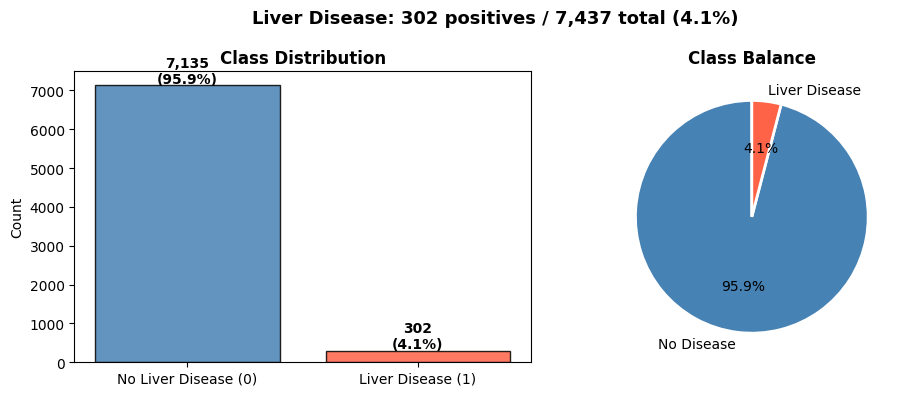

Imbalance ratio: 23.6:1 → using class_weight="balanced" throughout


In [4]:
# 2.1 Class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df[TARGET].value_counts().sort_index()
bars = axes[0].bar(['No Liver Disease (0)', 'Liver Disease (1)'],
                   counts.values, color=['steelblue', 'tomato'],
                   edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 60, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Disease', 'Liver Disease'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontweight='bold')
plt.suptitle(f'Liver Disease: {counts[1]:,} positives / {len(df):,} total ({counts[1]/len(df)*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f}:1 → using class_weight="balanced" throughout')

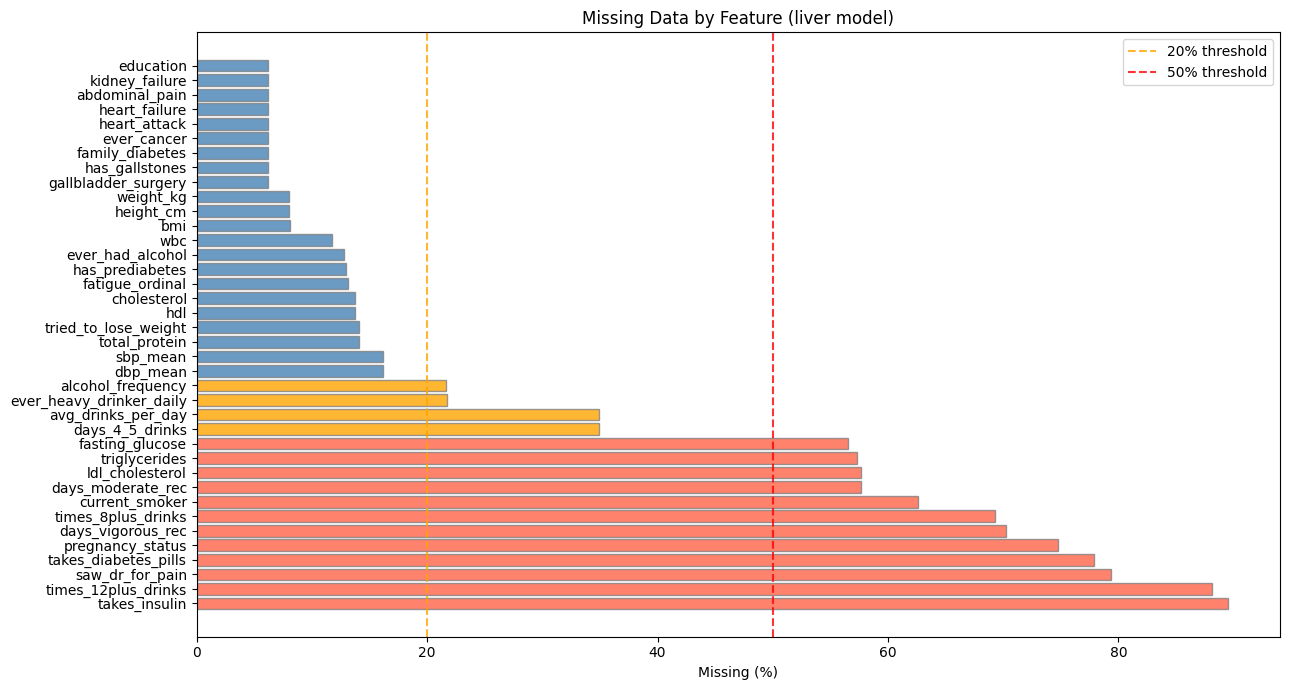

Features with any missing: 38/59
Features >50% missing (use miss flags): 12
Features >20% missing: 16


In [5]:
# 2.2 Missing data
feat_cols = [c for c in df.columns if c != TARGET]
miss = df[feat_cols].isnull().mean().sort_values(ascending=False)
miss_nz = miss[miss > 0]

fig, ax = plt.subplots(figsize=(13, 7))
colors = ['tomato' if v > 0.5 else 'orange' if v > 0.2 else 'steelblue'
          for v in miss_nz.values]
ax.barh(miss_nz.index, miss_nz.values * 100, color=colors, edgecolor='gray', alpha=0.8)
ax.axvline(20, color='orange', ls='--', alpha=0.8, label='20% threshold')
ax.axvline(50, color='red',    ls='--', alpha=0.8, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Feature (liver model)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Features with any missing: {len(miss_nz)}/{len(feat_cols)}')
print(f'Features >50% missing (use miss flags): {(miss>0.5).sum()}')
print(f'Features >20% missing: {(miss>0.2).sum()}')

In [6]:
# 2.3 Feature distributions by target — Mann-Whitney U test
from scipy.stats import mannwhitneyu

num_feats = df[feat_cols].select_dtypes(include='number').columns.tolist()
results = []
for feat in num_feats:
    g0 = df.loc[df[TARGET]==0, feat].dropna()
    g1 = df.loc[df[TARGET]==1, feat].dropna()
    if len(g1) < 5:
        continue
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    results.append({'feature': feat, 'p_value': p,
                    'mean_neg': g0.mean(), 'mean_pos': g1.mean()})

mw_df = pd.DataFrame(results).sort_values('p_value')
print('Top 20 features by Mann-Whitney U p-value:')
print(mw_df.head(20).to_string(index=False))

Top 20 features by Mann-Whitney U p-value:
                 feature      p_value  mean_neg  mean_pos
        ever_hepatitis_c 3.456985e-89  2.010231  1.983444
               med_count 2.668421e-29  2.056342  3.500000
               age_years 3.299418e-26 41.813875 50.715232
        ever_hepatitis_b 2.799923e-24  2.013875  2.119205
          general_health 9.951547e-24  2.702313  3.341060
        trouble_sleeping 2.793946e-20  1.751086  1.506623
      dr_said_reduce_fat 3.182388e-17  1.718851  1.486755
  healthcare_visits_year 3.259090e-16  2.310582  3.026490
  doctor_said_overweight 6.059971e-14  1.627610  1.403974
            ever_high_bp 1.447635e-13  1.728521  1.546358
          abdominal_pain 5.127263e-13  1.793171  1.632107
  dr_said_control_weight 5.951545e-13  1.733987  1.543046
   ever_high_cholesterol 1.438781e-12  1.774352  1.642384
          has_gallstones 1.153572e-10  1.930358  1.832776
ever_heavy_drinker_daily 1.043476e-09  1.867396  1.721116
      overnight_hospital 4.37

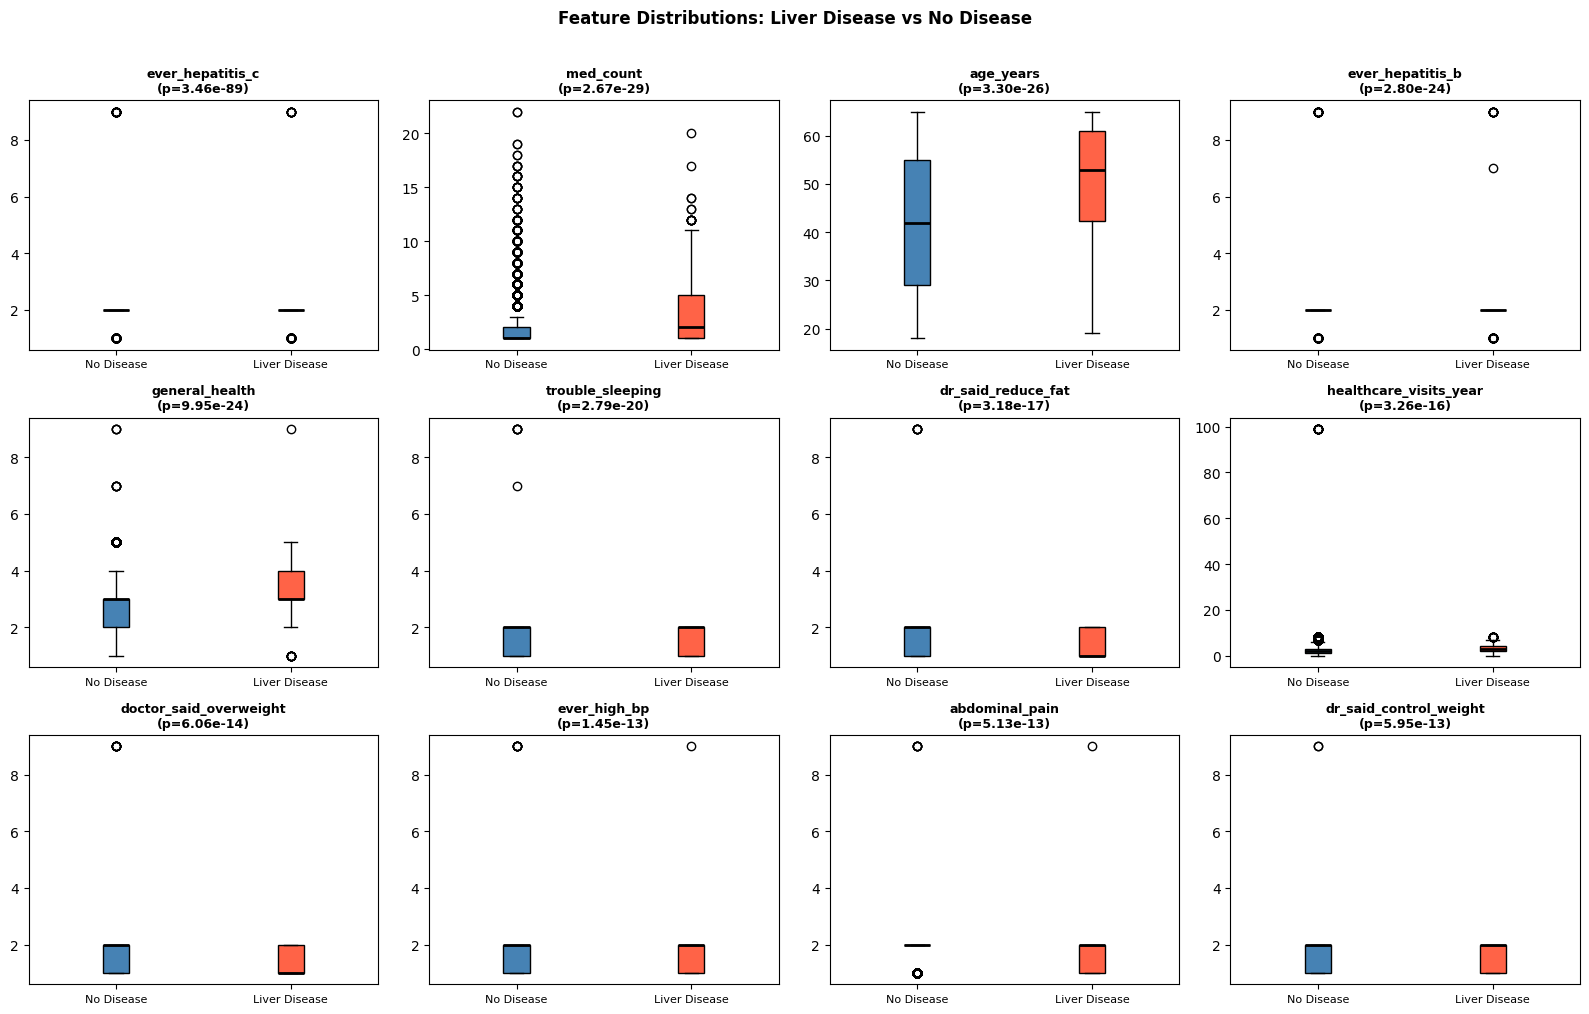

In [7]:
# Box plots for top 12 most significant features
top_feats = mw_df.head(12)['feature'].tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, feat in enumerate(top_feats):
    ax = axes[i//4, i%4]
    data = [df.loc[df[TARGET]==0, feat].dropna(), df.loc[df[TARGET]==1, feat].dropna()]
    bp = ax.boxplot(data, labels=['No Disease', 'Liver Disease'],
                    patch_artist=True, medianprops={'color': 'black', 'lw': 2})
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    p = mw_df.loc[mw_df['feature']==feat, 'p_value'].values[0]
    ax.set_title(f'{feat}\n(p={p:.2e})', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
plt.suptitle('Feature Distributions: Liver Disease vs No Disease', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

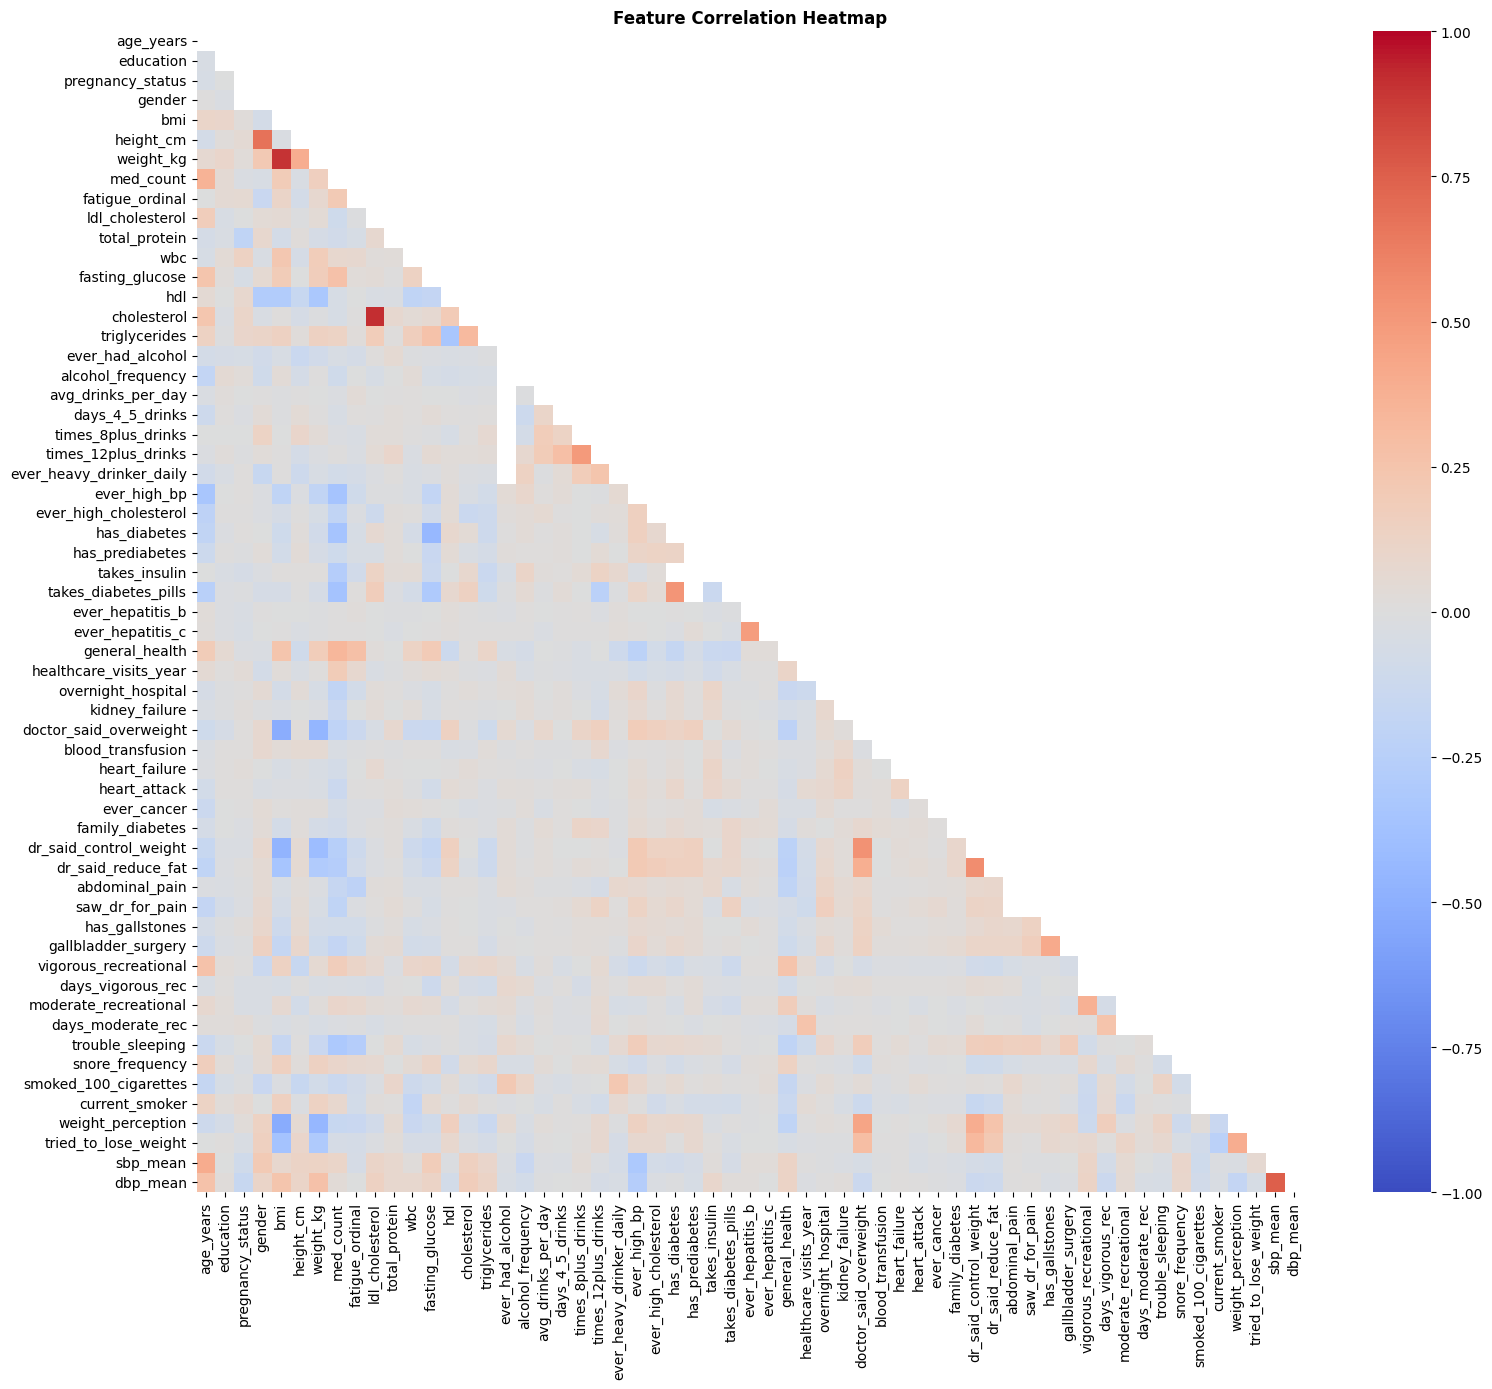

Highly correlated pairs (|r| > 0.8):
  ldl_cholesterol vs cholesterol: r=0.919
  bmi vs weight_kg: r=0.902


In [8]:
# 2.4 Correlation heatmap (numeric features)
corr_feats = df[num_feats].corr()
mask = np.triu(np.ones_like(corr_feats, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_feats, mask=mask, cmap='coolwarm', center=0,
            annot=False, ax=ax, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
hi_corr = [(corr_feats.columns[i], corr_feats.columns[j], corr_feats.iloc[i,j])
           for i in range(len(corr_feats)) for j in range(i+1, len(corr_feats))
           if abs(corr_feats.iloc[i,j]) > 0.8]
if hi_corr:
    print('Highly correlated pairs (|r| > 0.8):')
    for a, b, r in sorted(hi_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a} vs {b}: r={r:.3f}')

## Section 3: Feature Groups

Split features into two domains for ensemble modelling and interpretability.

- **LAB_FEATURES**: Demographics + blood panels available from routine clinical assessment  
- **QUEST_FEATURES**: Questionnaire-only features (alcohol, diabetes, hepatitis, obesity, lifestyle)

In [9]:
# ── Define feature groups ───────────────────────────────────────────────────
LAB_FEATURES = [f for f in [
    'age_years', 'gender', 'education', 'pregnancy_status',
    'bmi', 'height_cm', 'weight_kg', 'med_count', 'fatigue_ordinal',
    'sbp_mean', 'dbp_mean',
    'ldl_cholesterol', 'total_protein', 'wbc',
    'fasting_glucose', 'hdl', 'cholesterol', 'triglycerides',
    # circadian/exercise (if present)
    'cos_weekday_wake', 'sin_weekday_bedtime', 'sin_weekday_wake',
    'social_jetlag', 'moderate_exercise', 'vigorous_exercise', 'ever_heavy_drinker',
] if f in df.columns]

QUEST_FEATURES = [f for f in [
    # Alcohol
    'ever_had_alcohol', 'alcohol_frequency', 'avg_drinks_per_day',
    'days_4_5_drinks', 'times_8plus_drinks', 'times_12plus_drinks',
    'ever_heavy_drinker_daily',
    # Metabolic syndrome
    'ever_high_bp', 'ever_high_cholesterol',
    'has_diabetes', 'has_prediabetes', 'takes_insulin', 'takes_diabetes_pills',
    # Viral hepatitis
    'ever_hepatitis_b', 'ever_hepatitis_c',
    # General health
    'general_health', 'healthcare_visits_year', 'overnight_hospital',
    # Comorbidities
    'kidney_failure', 'doctor_said_overweight', 'blood_transfusion',
    'heart_failure', 'heart_attack', 'ever_cancer',
    'family_diabetes', 'dr_said_control_weight', 'dr_said_reduce_fat',
    # GI / hepatobiliary
    'abdominal_pain', 'saw_dr_for_pain', 'has_gallstones', 'gallbladder_surgery',
    # Physical activity
    'vigorous_recreational', 'days_vigorous_rec', 'moderate_recreational', 'days_moderate_rec',
    # Sleep
    'trouble_sleeping', 'snore_frequency',
    # Smoking
    'smoked_100_cigarettes', 'current_smoker',
    # Weight perception
    'weight_perception', 'tried_to_lose_weight',
] if f in df.columns]

ALL_FEATURES = list(dict.fromkeys(LAB_FEATURES + QUEST_FEATURES))

print(f'LAB_FEATURES:   {len(LAB_FEATURES)} features')
print(f'QUEST_FEATURES: {len(QUEST_FEATURES)} features')
print(f'ALL_FEATURES:   {len(ALL_FEATURES)} features (deduplicated)')
print(f'\nLAB_FEATURES: {LAB_FEATURES}')
print(f'\nQUEST_FEATURES: {QUEST_FEATURES}')

LAB_FEATURES:   18 features
QUEST_FEATURES: 41 features
ALL_FEATURES:   59 features (deduplicated)

LAB_FEATURES: ['age_years', 'gender', 'education', 'pregnancy_status', 'bmi', 'height_cm', 'weight_kg', 'med_count', 'fatigue_ordinal', 'sbp_mean', 'dbp_mean', 'ldl_cholesterol', 'total_protein', 'wbc', 'fasting_glucose', 'hdl', 'cholesterol', 'triglycerides']

QUEST_FEATURES: ['ever_had_alcohol', 'alcohol_frequency', 'avg_drinks_per_day', 'days_4_5_drinks', 'times_8plus_drinks', 'times_12plus_drinks', 'ever_heavy_drinker_daily', 'ever_high_bp', 'ever_high_cholesterol', 'has_diabetes', 'has_prediabetes', 'takes_insulin', 'takes_diabetes_pills', 'ever_hepatitis_b', 'ever_hepatitis_c', 'general_health', 'healthcare_visits_year', 'overnight_hospital', 'kidney_failure', 'doctor_said_overweight', 'blood_transfusion', 'heart_failure', 'heart_attack', 'ever_cancer', 'family_diabetes', 'dr_said_control_weight', 'dr_said_reduce_fat', 'abdominal_pain', 'saw_dr_for_pain', 'has_gallstones', 'gallbla

## Section 4: Preprocessing

Add missingness flags for every column with NaN — clinical missingness is itself a signal.  
Use integer-index train/test split to avoid DataFrame alignment issues.

In [10]:
# ── Missingness flags ───────────────────────────────────────────────────────
def add_missing_flags(df_feat):
    flags = {f'{c}_miss': df_feat[c].isnull().astype(int)
             for c in df_feat.columns if df_feat[c].isnull().any()}
    return pd.concat([df_feat, pd.DataFrame(flags, index=df_feat.index)], axis=1) \
           if flags else df_feat

X_lab_full   = add_missing_flags(df[LAB_FEATURES])
X_quest_full = add_missing_flags(df[QUEST_FEATURES])
X_all_full   = add_missing_flags(df[ALL_FEATURES])
y_full       = df[TARGET]

print(f'X_lab_full:   {X_lab_full.shape}')
print(f'X_quest_full: {X_quest_full.shape}')
print(f'X_all_full:   {X_all_full.shape}')

# ── Integer-index train/test split ──────────────────────────────────────────
_idx = np.arange(len(df))
tr_idx, te_idx = train_test_split(_idx, test_size=0.2,
                                   stratify=y_full.values, random_state=SEED)
X_tr = X_all_full.iloc[tr_idx]; X_te = X_all_full.iloc[te_idx]
y_tr = y_full.iloc[tr_idx];     y_te = y_full.iloc[te_idx]

print(f'\nTrain: {X_tr.shape}, positives: {y_tr.sum()} ({y_tr.mean()*100:.1f}%)')
print(f'Test:  {X_te.shape}, positives: {y_te.sum()} ({y_te.mean()*100:.1f}%)')

X_lab_full:   (7437, 33)
X_quest_full: (7437, 64)
X_all_full:   (7437, 97)

Train: (5949, 97), positives: 242 (4.1%)
Test:  (1488, 97), positives: 60 (4.0%)


In [11]:
# ── Pipeline definitions ─────────────────────────────────────────────────────
def make_lr(C=1.0, penalty='l2', solver=None):
    if solver is None:
        solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(penalty=penalty, C=C,
                                   class_weight='balanced',
                                   max_iter=2000, random_state=SEED,
                                   solver=solver))
    ])

def make_rf(n_estimators=200):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=n_estimators,
                                        class_weight='balanced',
                                        random_state=SEED, n_jobs=-1))
    ])

def evaluate(model, X_tr, X_te, y_tr, y_te, name='', thr=0.3):
    model.fit(X_tr, y_tr)
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= thr).astype(int)
    return {
        'Model': name,
        'ROC-AUC':       round(roc_auc_score(y_te, prob), 4),
        'Avg Precision': round(average_precision_score(y_te, prob), 4),
        'Recall':        round(recall_score(y_te, pred, zero_division=0), 4),
        'Precision':     round(precision_score(y_te, pred, zero_division=0), 4),
        'Accuracy':      round(accuracy_score(y_te, pred), 4),
        'F1':            round(f1_score(y_te, pred, zero_division=0), 4),
    }

THR = 0.3
print('Pipeline definitions ready. THR =', THR)

Pipeline definitions ready. THR = 0.3


## Section 5: Baseline Models — LR L2 and LR L1

Train on full feature set with missingness flags. Evaluate at threshold = 0.3.

In [12]:
# ── Train LR L2 and LR L1 ──────────────────────────────────────────────────
lr_l2 = make_lr(C=1.0, penalty='l2')
lr_l1 = make_lr(C=1.0, penalty='l1')

lr_l2.fit(X_tr, y_tr)
lr_l1.fit(X_tr, y_tr)

for name, model in [('LR L2 (all)', lr_l2), ('LR L1 (all)', lr_l1)]:
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= THR).astype(int)
    print(f'\n── {name} ──')
    print(f'  ROC-AUC:       {roc_auc_score(y_te, prob):.4f}')
    print(f'  Avg Precision: {average_precision_score(y_te, prob):.4f}')
    print(f'  Recall@{THR}:   {recall_score(y_te, pred):.4f}')
    print(f'  Precision@{THR}:{precision_score(y_te, pred, zero_division=0):.4f}')
    print(f'  F1@{THR}:       {f1_score(y_te, pred):.4f}')
    print(f'  Confusion matrix:\n{confusion_matrix(y_te, pred)}')


── LR L2 (all) ──
  ROC-AUC:       0.7071
  Avg Precision: 0.1188
  Recall@0.3:   0.8000
  Precision@0.3:0.0589
  F1@0.3:       0.1097
  Confusion matrix:
[[661 767]
 [ 12  48]]

── LR L1 (all) ──
  ROC-AUC:       0.7164
  Avg Precision: 0.1199
  Recall@0.3:   0.8167
  Precision@0.3:0.0596
  F1@0.3:       0.1111
  Confusion matrix:
[[655 773]
 [ 11  49]]


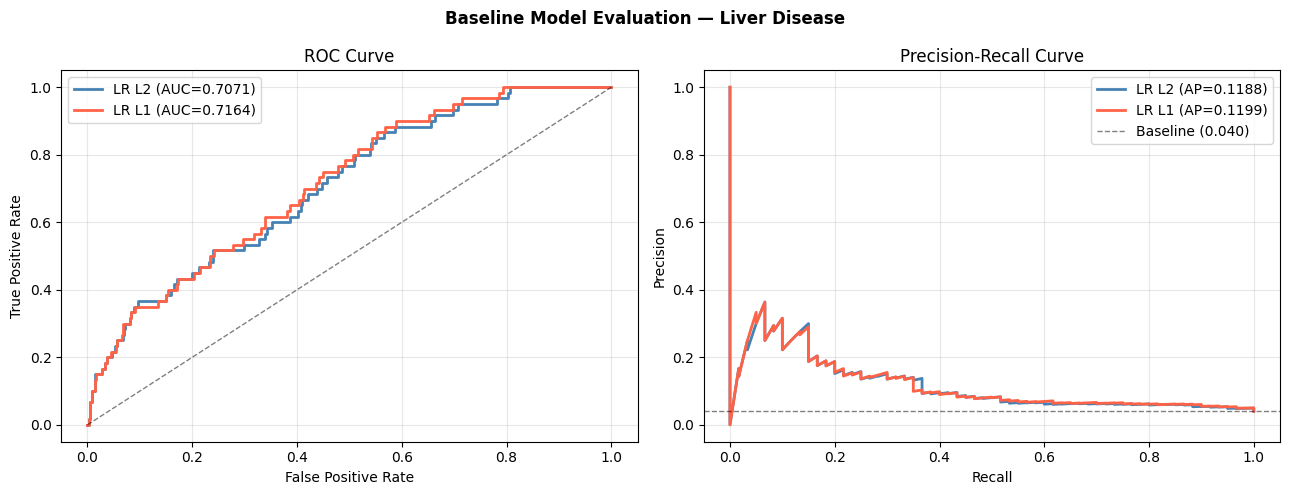

In [13]:
# ── ROC and Precision-Recall curves ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model, color in [('LR L2', lr_l2, 'steelblue'), ('LR L1', lr_l1, 'tomato')]:
    prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')

    prec, rec, _ = precision_recall_curve(y_te, prob)
    ap = average_precision_score(y_te, prob)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.4f})')

axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(y_te.mean(), color='k', ls='--', lw=1, alpha=0.5,
                label=f'Baseline ({y_te.mean():.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Baseline Model Evaluation — Liver Disease', fontweight='bold')
plt.tight_layout()
plt.show()

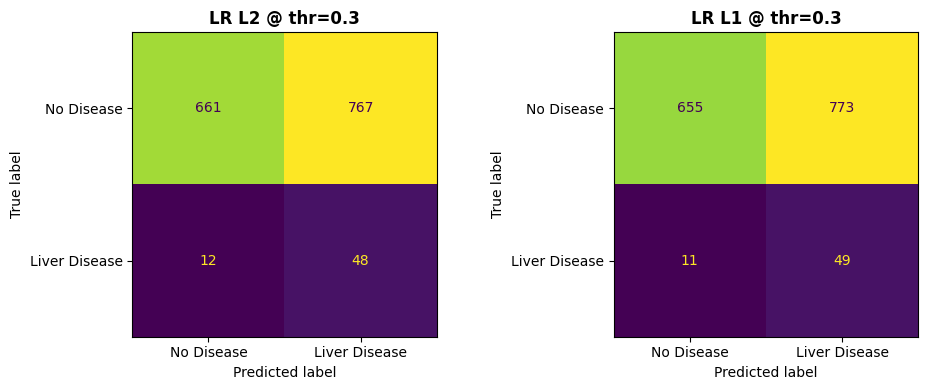

In [14]:
# ── Confusion matrices @ thr=0.3 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, [('LR L2', lr_l2), ('LR L1', lr_l1)]):
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= THR).astype(int)
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Liver Disease']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} @ thr={THR}', fontweight='bold')
plt.tight_layout()
plt.show()

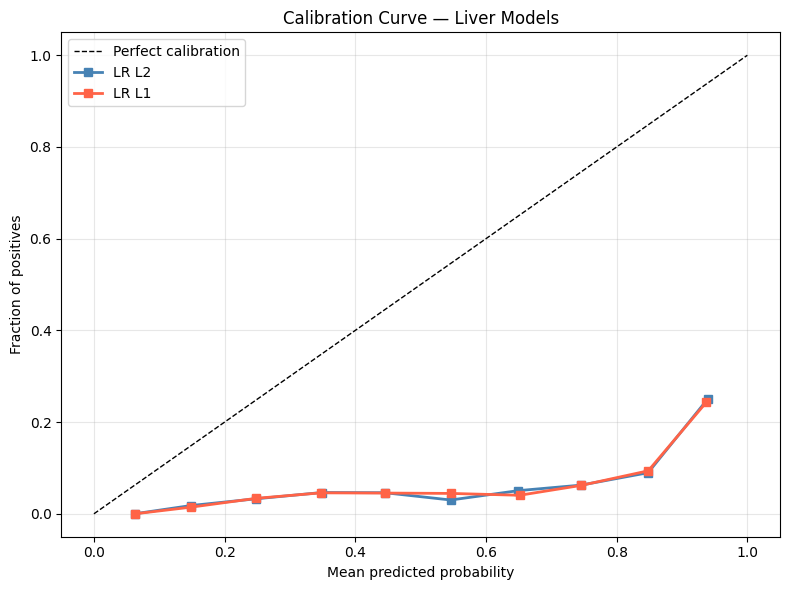

In [15]:
# ── Calibration curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
for name, model, color in [('LR L2', lr_l2, 'steelblue'), ('LR L1', lr_l1, 'tomato')]:
    prob = model.predict_proba(X_te)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_te, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=color, lw=2, label=name)
ax.set(xlabel='Mean predicted probability', ylabel='Fraction of positives',
       title='Calibration Curve — Liver Models')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

LR L2: optimal thr=0.28 → recall=0.8500, precision=0.0594


LR L1: optimal thr=0.29 → recall=0.8667, precision=0.0615


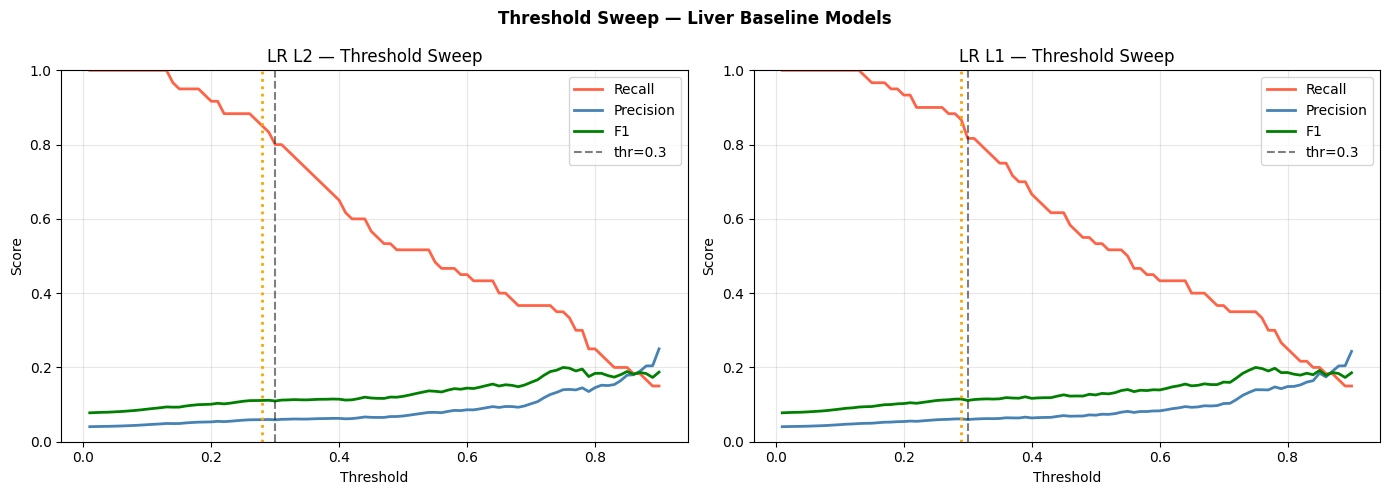

In [16]:
# ── Threshold sweep: find optimal threshold for recall ≥ 0.85 ───────────────
thrs = np.arange(0.01, 0.91, 0.01)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model, color) in zip(axes, [('LR L2', lr_l2, 'steelblue'), ('LR L1', lr_l1, 'tomato')]):
    prob = model.predict_proba(X_te)[:, 1]
    thr_df = pd.DataFrame([{
        'thr': t,
        'recall':    recall_score(y_te, (prob>=t).astype(int), zero_division=0),
        'precision': precision_score(y_te, (prob>=t).astype(int), zero_division=0),
        'f1':        f1_score(y_te, (prob>=t).astype(int), zero_division=0),
    } for t in thrs])
    ax.plot(thr_df['thr'], thr_df['recall'],    lw=2, label='Recall',    color='tomato')
    ax.plot(thr_df['thr'], thr_df['precision'], lw=2, label='Precision', color='steelblue')
    ax.plot(thr_df['thr'], thr_df['f1'],        lw=2, label='F1',        color='green')
    ax.axvline(THR, color='k', ls='--', alpha=0.5, label=f'thr={THR}')
    ax.set(xlabel='Threshold', ylabel='Score', title=f'{name} — Threshold Sweep', ylim=[0,1])
    ax.legend(); ax.grid(alpha=0.3)
    candidates = thr_df[thr_df['recall'] >= 0.85]
    if not candidates.empty:
        opt = candidates.iloc[-1]
        ax.axvline(opt['thr'], color='orange', ls=':', lw=2, label=f'opt_thr={opt["thr"]:.2f}')
        print(f'{name}: optimal thr={opt["thr"]:.2f} → recall={opt["recall"]:.4f}, precision={opt["precision"]:.4f}')
    else:
        print(f'{name}: recall ≥ 0.85 not achievable at any threshold')

plt.suptitle('Threshold Sweep — Liver Baseline Models', fontweight='bold')
plt.tight_layout()
plt.show()

LR L2:
  CV ROC-AUC:    0.7302 ± 0.0109
  CV Avg Prec:   0.1183 ± 0.0072
  CV Recall:     0.5990 ± 0.0509


LR L1:
  CV ROC-AUC:    0.7333 ± 0.0116
  CV Avg Prec:   0.1184 ± 0.0074
  CV Recall:     0.5990 ± 0.0549


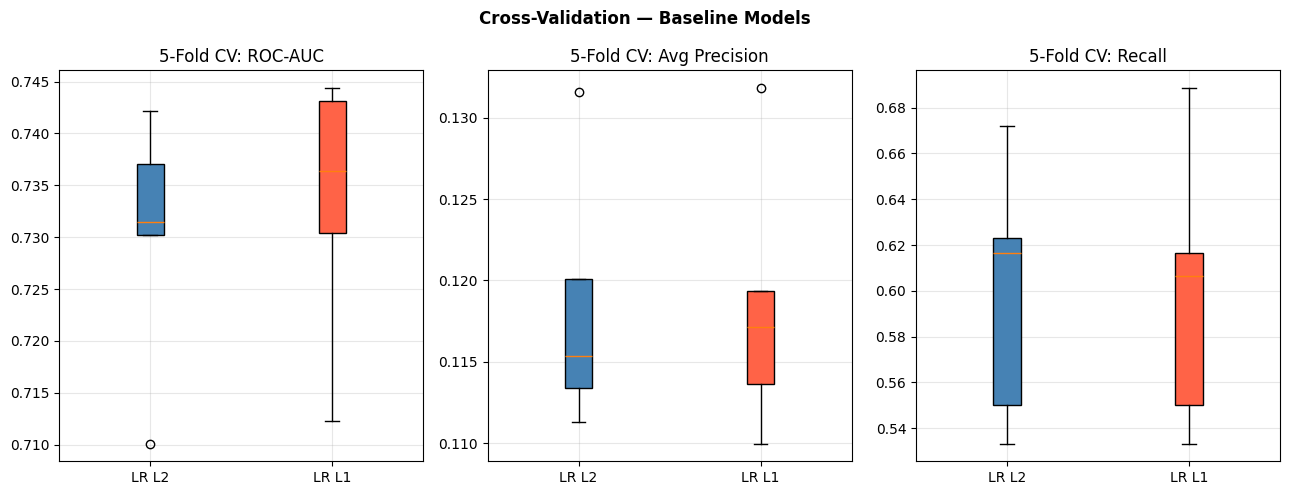

In [17]:
# ── 5-fold CV box plots ──────────────────────────────────────────────────────
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}
for name, model, X in [('LR L2', make_lr(), X_all_full), ('LR L1', make_lr(penalty='l1'), X_all_full)]:
    scores = cross_validate(model, X, y_full, cv=cv5,
                            scoring=['roc_auc', 'average_precision', 'recall'],
                            return_train_score=False)
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  CV ROC-AUC:    {scores["test_roc_auc"].mean():.4f} ± {scores["test_roc_auc"].std():.4f}')
    print(f'  CV Avg Prec:   {scores["test_average_precision"].mean():.4f} ± {scores["test_average_precision"].std():.4f}')
    print(f'  CV Recall:     {scores["test_recall"].mean():.4f} ± {scores["test_recall"].std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metrics = ['test_roc_auc', 'test_average_precision', 'test_recall']
titles  = ['ROC-AUC', 'Avg Precision', 'Recall']
for ax, metric, title in zip(axes, metrics, titles):
    data  = [cv_results[n][metric] for n in cv_results]
    bp    = ax.boxplot(data, labels=list(cv_results.keys()), patch_artist=True)
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
        patch.set_facecolor(color)
    ax.set_title(f'5-Fold CV: {title}')
    ax.grid(alpha=0.3)
plt.suptitle('Cross-Validation — Baseline Models', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6: Tree Models — Random Forest & XGBoost

Expected finding: LR typically matches or beats tree models on recall at thr=0.3.  
Tree models need a much lower threshold (~0.03) to reach recall ≥ 0.85.

In [18]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    print('XGBoost not available — skipping. Install with: pip install xgboost')
    HAS_XGB = False

# ── Random Forest ────────────────────────────────────────────────────────────
rf = make_rf()
rf.fit(X_tr, y_tr)
rf_prob = rf.predict_proba(X_te)[:, 1]
rf_pred = (rf_prob >= THR).astype(int)
print('── Random Forest ──')
print(f'  ROC-AUC:      {roc_auc_score(y_te, rf_prob):.4f}')
print(f'  Recall@{THR}:  {recall_score(y_te, rf_pred):.4f}')
print(f'  Precision@{THR}:{precision_score(y_te, rf_pred, zero_division=0):.4f}')

# ── XGBoost ─────────────────────────────────────────────────────────────────
if HAS_XGB:
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    xgb_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=200, scale_pos_weight=spw,
                              random_state=SEED, eval_metric='logloss',
                              verbosity=0))
    ])
    xgb_pipe.fit(X_tr, y_tr)
    xgb_prob = xgb_pipe.predict_proba(X_te)[:, 1]
    xgb_pred = (xgb_prob >= THR).astype(int)
    print('\n── XGBoost ──')
    print(f'  ROC-AUC:      {roc_auc_score(y_te, xgb_prob):.4f}')
    print(f'  Recall@{THR}:  {recall_score(y_te, xgb_pred):.4f}')
    print(f'  Precision@{THR}:{precision_score(y_te, xgb_pred, zero_division=0):.4f}')

── Random Forest ──
  ROC-AUC:      0.7840
  Recall@0.3:  0.1000
  Precision@0.3:0.7500



── XGBoost ──
  ROC-AUC:      0.7238
  Recall@0.3:  0.1833
  Precision@0.3:0.3333


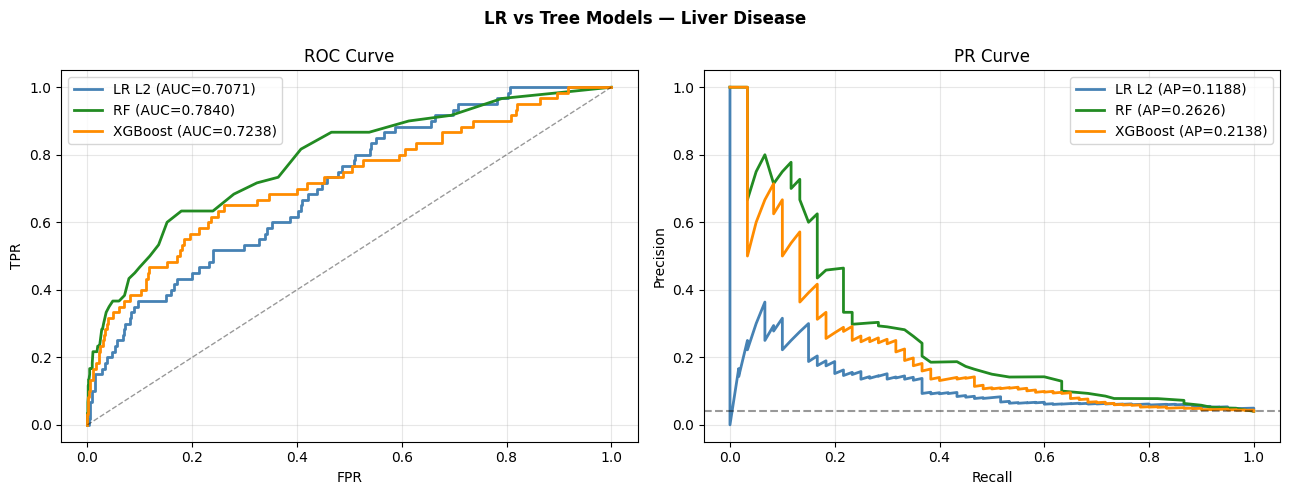

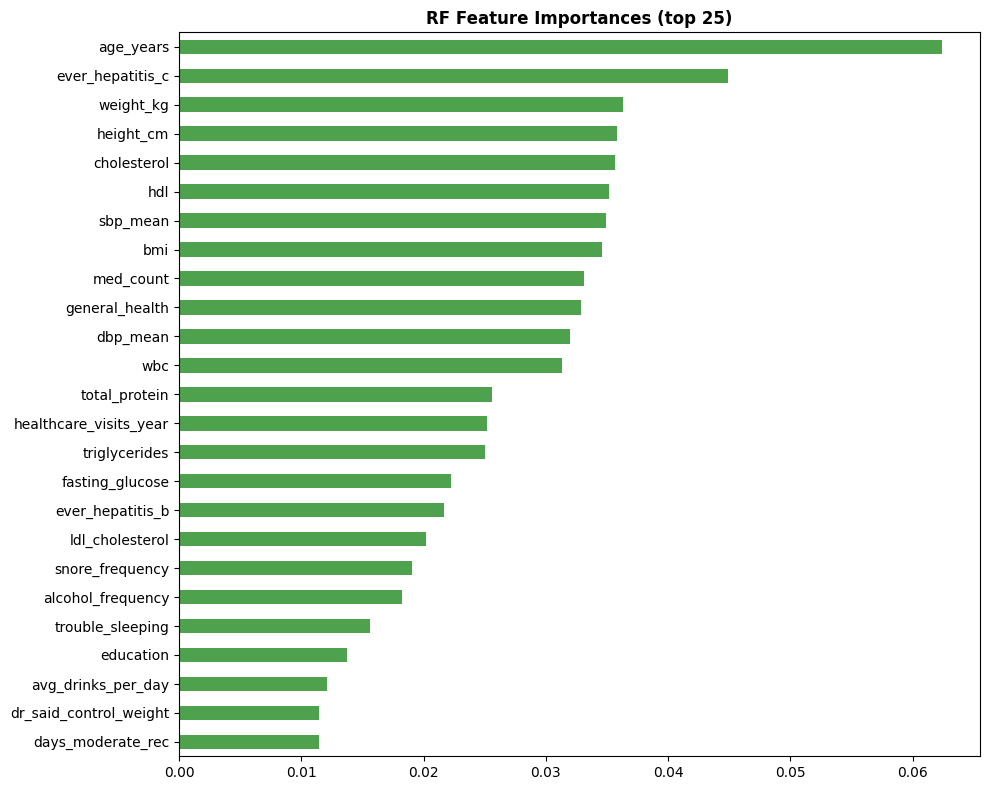

In [19]:
# ── ROC comparison: LR vs tree models ───────────────────────────────────────
models_to_plot = [('LR L2', lr_l2, 'steelblue'), ('RF', rf, 'forestgreen')]
if HAS_XGB:
    models_to_plot.append(('XGBoost', xgb_pipe, 'darkorange'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, model, color in models_to_plot:
    prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
    prec, rec, _ = precision_recall_curve(y_te, prob)
    ap = average_precision_score(y_te, prob)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.4f})')

axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].axhline(y_te.mean(), color='k', ls='--', alpha=0.4)
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('LR vs Tree Models — Liver Disease', fontweight='bold')
plt.tight_layout(); plt.show()

# ── RF feature importances ───────────────────────────────────────────────────
rf_imp = pd.Series(rf.named_steps['clf'].feature_importances_,
                   index=X_all_full.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
rf_imp.head(25).plot.barh(ax=ax, color='forestgreen', alpha=0.8)
ax.set_title('RF Feature Importances (top 25)', fontweight='bold')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## Section 7: Calibration

Calibrate RF (and XGBoost if available) with isotonic regression (cv=3).  
Note: calibration compresses probabilities toward 0.5 — recall at thr=0.3 gets worse.
Tree models need thr≈0.03 to recover recall ≥ 0.85.

── Calibrated RF ──
  ROC-AUC:      0.7937
  Recall@0.3:  0.1500
  Precision@0.3:0.4286



── Calibrated XGBoost ──
  ROC-AUC:      0.7479
  Recall@0.3:  0.1000
  Precision@0.3:0.5000


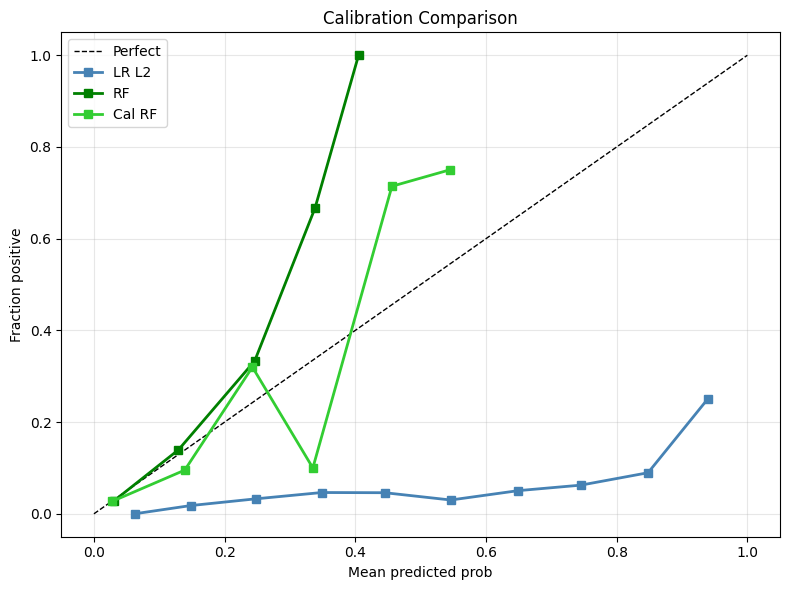

In [20]:
from sklearn.calibration import CalibratedClassifierCV

cal_rf = CalibratedClassifierCV(make_rf(), method='isotonic', cv=3)
cal_rf.fit(X_tr, y_tr)
cal_rf_prob = cal_rf.predict_proba(X_te)[:, 1]
cal_rf_pred = (cal_rf_prob >= THR).astype(int)
print('── Calibrated RF ──')
print(f'  ROC-AUC:      {roc_auc_score(y_te, cal_rf_prob):.4f}')
print(f'  Recall@{THR}:  {recall_score(y_te, cal_rf_pred):.4f}')
print(f'  Precision@{THR}:{precision_score(y_te, cal_rf_pred, zero_division=0):.4f}')

if HAS_XGB:
    cal_xgb = CalibratedClassifierCV(xgb_pipe, method='isotonic', cv=3)
    cal_xgb.fit(X_tr, y_tr)
    cal_xgb_prob = cal_xgb.predict_proba(X_te)[:, 1]
    cal_xgb_pred = (cal_xgb_prob >= THR).astype(int)
    print('\n── Calibrated XGBoost ──')
    print(f'  ROC-AUC:      {roc_auc_score(y_te, cal_xgb_prob):.4f}')
    print(f'  Recall@{THR}:  {recall_score(y_te, cal_xgb_pred):.4f}')
    print(f'  Precision@{THR}:{precision_score(y_te, cal_xgb_pred, zero_division=0):.4f}')

# Calibration comparison plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect')
for name, model, color in [('LR L2', lr_l2, 'steelblue'), ('RF', rf, 'green'),
                             ('Cal RF', cal_rf, 'limegreen')]:
    prob = model.predict_proba(X_te)[:,1]
    fp, mp = calibration_curve(y_te, prob, n_bins=10)
    ax.plot(mp, fp, 's-', color=color, lw=2, label=name)
ax.set(title='Calibration Comparison', xlabel='Mean predicted prob', ylabel='Fraction positive')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Section 8: Ensemble — Domain-Split Stacking

Three base models:
1. `LR_labs` — trained on LAB features only  
2. `LR_quest` — trained on questionnaire features only  
3. `RF_all` — trained on all features

OOF stacking with `cross_val_predict` to avoid data leakage.  
Key question: does `LR_quest` alone match the full stack?

In [21]:
# ── OOF stacking ────────────────────────────────────────────────────────────
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

oof_lab   = cross_val_predict(make_lr(),    X_lab_full,   y_full, cv=cv3, method='predict_proba')[:,1]
oof_quest = cross_val_predict(make_lr(),    X_quest_full, y_full, cv=cv3, method='predict_proba')[:,1]
oof_rf    = cross_val_predict(make_rf(100), X_all_full,   y_full, cv=cv3, method='predict_proba')[:,1]

meta_X = np.column_stack([oof_lab, oof_quest, oof_rf])

# ── Retrain base models on full train set ────────────────────────────────────
lr_labs  = make_lr()
lr_quest = make_lr()
rf_all   = make_rf()

X_lab_tr   = X_lab_full.iloc[tr_idx];   X_lab_te   = X_lab_full.iloc[te_idx]
X_quest_tr = X_quest_full.iloc[tr_idx]; X_quest_te = X_quest_full.iloc[te_idx]

lr_labs.fit(X_lab_tr, y_tr)
lr_quest.fit(X_quest_tr, y_tr)
rf_all.fit(X_tr, y_tr)

# ── Meta-learner ─────────────────────────────────────────────────────────────
meta_lr = LogisticRegression(C=1.0, class_weight='balanced', random_state=SEED)
meta_lr.fit(meta_X[tr_idx], y_tr)

te_lab   = lr_labs.predict_proba(X_lab_te)[:,1]
te_quest = lr_quest.predict_proba(X_quest_te)[:,1]
te_rf    = rf_all.predict_proba(X_te)[:,1]
stack_prob = meta_lr.predict_proba(np.column_stack([te_lab, te_quest, te_rf]))[:,1]

print('── Stacked Ensemble ──')
print(f'  ROC-AUC:       {roc_auc_score(y_te, stack_prob):.4f}')
print(f'  Recall@{THR}:   {recall_score(y_te, (stack_prob>=THR).astype(int)):.4f}')
print(f'  Precision@{THR}:{precision_score(y_te, (stack_prob>=THR).astype(int), zero_division=0):.4f}')
print(f'\nMeta-learner weights (labs, quest, rf): {meta_lr.coef_[0].round(3)}')

# ── LR Quest alone for comparison ───────────────────────────────────────────
print('\n── LR Quest (alone) ──')
q_prob = lr_quest.predict_proba(X_quest_te)[:,1]
print(f'  ROC-AUC:       {roc_auc_score(y_te, q_prob):.4f}')
print(f'  Recall@{THR}:   {recall_score(y_te, (q_prob>=THR).astype(int)):.4f}')
print(f'  Precision@{THR}:{precision_score(y_te, (q_prob>=THR).astype(int), zero_division=0):.4f}')

── Stacked Ensemble ──
  ROC-AUC:       0.7979
  Recall@0.3:   0.9167
  Precision@0.3:0.0618

Meta-learner weights (labs, quest, rf): [ 1.481  1.649 10.188]

── LR Quest (alone) ──
  ROC-AUC:       0.7108
  Recall@0.3:   0.8500
  Precision@0.3:0.0569


In [22]:
# ── Soft vote ensembles ──────────────────────────────────────────────────────
vote_eq      = (te_lab + te_quest + te_rf) / 3
vote_qheavy  = 0.15*te_lab + 0.60*te_quest + 0.25*te_rf

for name, prob in [('Soft-Vote Equal', vote_eq), ('Soft-Vote Quest-Heavy', vote_qheavy)]:
    pred = (prob >= THR).astype(int)
    print(f'{name}: AUC={roc_auc_score(y_te, prob):.4f}  '
          f'Recall={recall_score(y_te, pred):.4f}  '
          f'Prec={precision_score(y_te, pred, zero_division=0):.4f}')

Soft-Vote Equal: AUC=0.7585  Recall=0.7833  Prec=0.0739
Soft-Vote Quest-Heavy: AUC=0.7410  Recall=0.7667  Prec=0.0638


## Section 9: Master Comparison Table

In [23]:
# ── Build master comparison ──────────────────────────────────────────────────
results = []

# Retrain all on train split for fair comparison
models_master = {
    'LR L2 (all)':    (make_lr(),              X_tr, X_te),
    'LR L1 (all)':    (make_lr(penalty='l1'),  X_tr, X_te),
    'LR Labs':        (make_lr(),              X_lab_tr, X_lab_te),
    'LR Quest':       (make_lr(),              X_quest_tr, X_quest_te),
    'RF (all)':       (make_rf(),              X_tr, X_te),
}
if HAS_XGB:
    models_master['XGBoost'] = (Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=200,
                              scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
                              random_state=SEED, eval_metric='logloss', verbosity=0))
    ]), X_tr, X_te)
    models_master['Cal RF']  = (CalibratedClassifierCV(make_rf(), method='isotonic', cv=3), X_tr, X_te)

for name, (model, Xtr_, Xte_) in models_master.items():
    res = evaluate(model, Xtr_, Xte_, y_tr, y_te, name=name, thr=THR)
    results.append(res)

# Add ensemble models (already fitted)
for name, prob in [('Stack (LR meta)', stack_prob), ('Soft-Vote Equal', vote_eq),
                    ('Soft-Vote Quest-Heavy', vote_qheavy)]:
    pred = (prob >= THR).astype(int)
    results.append({'Model': name,
                    'ROC-AUC':       round(roc_auc_score(y_te, prob), 4),
                    'Avg Precision': round(average_precision_score(y_te, prob), 4),
                    'Recall':        round(recall_score(y_te, pred, zero_division=0), 4),
                    'Precision':     round(precision_score(y_te, pred, zero_division=0), 4),
                    'Accuracy':      round(accuracy_score(y_te, pred), 4),
                    'F1':            round(f1_score(y_te, pred, zero_division=0), 4)})

master = pd.DataFrame(results).set_index('Model')
print(master.to_string())

                       ROC-AUC  Avg Precision  Recall  Precision  Accuracy      F1
Model                                                                             
LR L2 (all)             0.7071         0.1188  0.8000     0.0589    0.4765  0.1097
LR L1 (all)             0.7164         0.1199  0.8167     0.0596    0.4731  0.1111
LR Labs                 0.6885         0.0925  0.9000     0.0551    0.3737  0.1038
LR Quest                0.7108         0.1183  0.8500     0.0569    0.4254  0.1066
RF (all)                0.7840         0.2626  0.1000     0.7500    0.9624  0.1765
XGBoost                 0.7238         0.2138  0.1833     0.3333    0.9523  0.2366
Cal RF                  0.7937         0.2590  0.1500     0.4286    0.9577  0.2222
Stack (LR meta)         0.7979         0.2325  0.9167     0.0618    0.4355  0.1158
Soft-Vote Equal         0.7585         0.1662  0.7833     0.0739    0.5954  0.1351
Soft-Vote Quest-Heavy   0.7410         0.1395  0.7667     0.0638    0.5370  0.1178


In [24]:
# ── Optimised threshold: highest thr where recall ≥ 0.85 ───────────────────
opt_rows = []
_fitted_models = {}
for name, (model, Xtr_, Xte_) in models_master.items():
    # get already-fitted probs
    if hasattr(model, 'predict_proba'):
        model.fit(Xtr_, y_tr)
        prob = model.predict_proba(Xte_)[:,1]
        _fitted_models[name] = prob

for name, prob in list(_fitted_models.items()) + [('Stack', stack_prob),
                                                    ('SV Equal', vote_eq)]:
    thr_df = pd.DataFrame([{'thr':t,
        'recall': recall_score(y_te, (prob>=t).astype(int), zero_division=0),
        'precision': precision_score(y_te, (prob>=t).astype(int), zero_division=0)}
        for t in np.arange(0.01,0.91,0.01)])
    cands = thr_df[thr_df['recall'] >= 0.85]
    if not cands.empty:
        opt = cands.iloc[-1]
        opt_rows.append({'Model': name, 'Opt thr': opt['thr'],
                         'Recall@opt': opt['recall'], 'Prec@opt': opt['precision']})
    else:
        opt_rows.append({'Model': name, 'Opt thr': np.nan,
                         'Recall@opt': np.nan, 'Prec@opt': np.nan})

opt_thr_df = pd.DataFrame(opt_rows).set_index('Model')
print('Optimised Threshold Table (recall ≥ 0.85):')
print(opt_thr_df.to_string())

Optimised Threshold Table (recall ≥ 0.85):
             Opt thr  Recall@opt  Prec@opt
Model                                     
LR L2 (all)     0.28    0.850000  0.059441
LR L1 (all)     0.29    0.866667  0.061538
LR Labs         0.34    0.850000  0.057368
LR Quest        0.30    0.850000  0.056856
RF (all)        0.03    0.866667  0.072524
XGBoost          NaN         NaN       NaN
Cal RF          0.02    0.850000  0.068919
Stack           0.36    0.866667  0.074392
SV Equal        0.28    0.850000  0.071529


## Section 10: Feature Selection — LR Questionnaire Model

Run bootstrap coefficient stability (500 resamples) + L1 regularisation path  
on `LR_quest` to identify STRONG / BORDERLINE / REMOVE tiers.

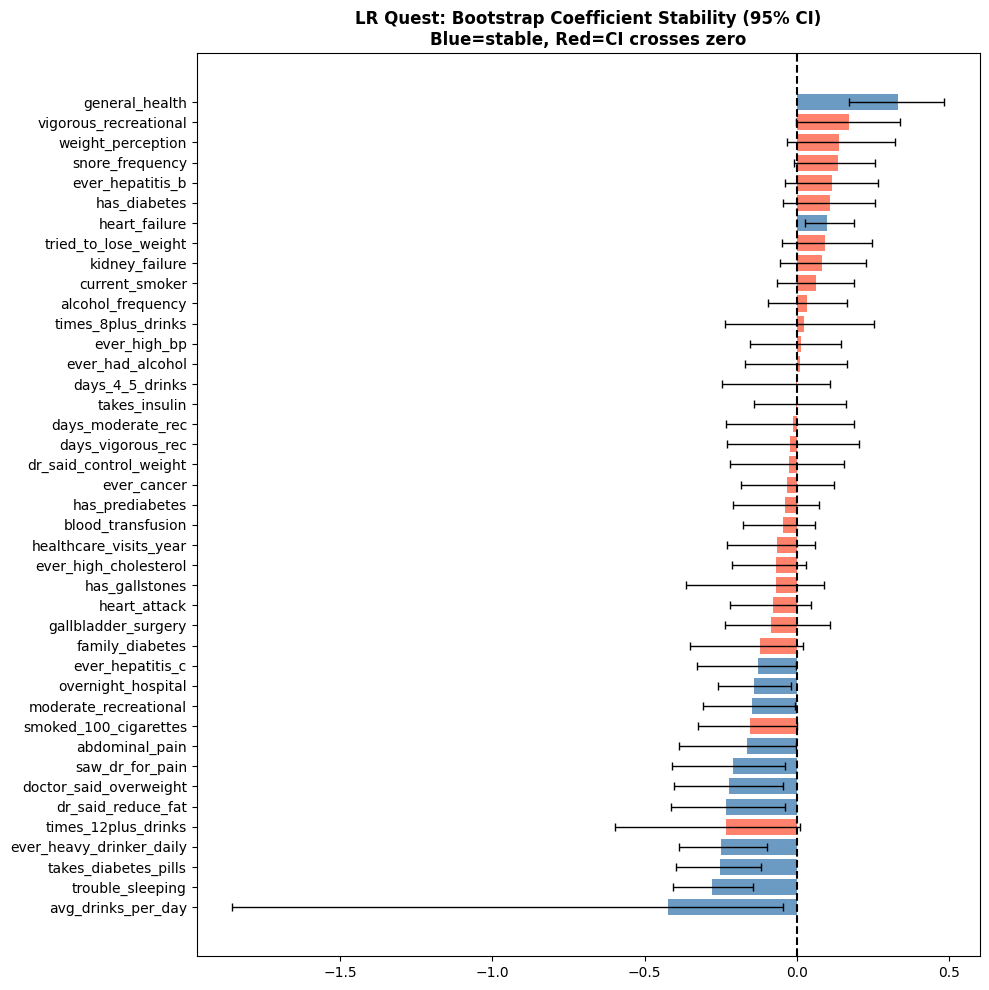


STABLE features (13): ['avg_drinks_per_day', 'trouble_sleeping', 'takes_diabetes_pills', 'ever_heavy_drinker_daily', 'dr_said_reduce_fat', 'doctor_said_overweight', 'saw_dr_for_pain', 'abdominal_pain', 'moderate_recreational', 'overnight_hospital', 'ever_hepatitis_c', 'heart_failure', 'general_health']
UNSTABLE features (28): ['times_12plus_drinks', 'smoked_100_cigarettes', 'family_diabetes', 'gallbladder_surgery', 'heart_attack', 'has_gallstones', 'ever_high_cholesterol', 'healthcare_visits_year', 'blood_transfusion', 'has_prediabetes', 'ever_cancer', 'dr_said_control_weight', 'days_vigorous_rec', 'days_moderate_rec', 'takes_insulin', 'days_4_5_drinks', 'ever_had_alcohol', 'ever_high_bp', 'times_8plus_drinks', 'alcohol_frequency', 'current_smoker', 'kidney_failure', 'tried_to_lose_weight', 'has_diabetes', 'ever_hepatitis_b', 'snore_frequency', 'weight_perception', 'vigorous_recreational']


In [25]:
# ── Bootstrap coefficient stability (500 resamples) ─────────────────────────
N_BOOT = 500
np.random.seed(SEED)

quest_base = [f for f in QUEST_FEATURES if f in df.columns]
X_proc = StandardScaler().fit_transform(
    SimpleImputer(strategy='median').fit_transform(df[quest_base]))

boot_coefs = np.zeros((N_BOOT, len(quest_base)))
lr_boot = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                              max_iter=2000, solver='lbfgs', random_state=SEED)
for i in range(N_BOOT):
    idx = np.random.choice(len(X_proc), len(X_proc), replace=True)
    lr_boot.fit(X_proc[idx], y_full.values[idx])
    boot_coefs[i] = lr_boot.coef_[0]

ci_lo = np.percentile(boot_coefs, 2.5,  axis=0)
ci_hi = np.percentile(boot_coefs, 97.5, axis=0)
mean_coef = boot_coefs.mean(axis=0)
ci_crosses_zero = (ci_lo < 0) & (ci_hi > 0)

boot_df = pd.DataFrame({'feature': quest_base, 'mean_coef': mean_coef,
                         'ci_lo': ci_lo, 'ci_hi': ci_hi,
                         'unstable': ci_crosses_zero}).sort_values('mean_coef')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['tomato' if u else 'steelblue' for u in boot_df['unstable']]
ax.barh(boot_df['feature'], boot_df['mean_coef'], color=colors, alpha=0.8)
ax.errorbar(boot_df['mean_coef'], boot_df['feature'],
            xerr=[boot_df['mean_coef']-boot_df['ci_lo'], boot_df['ci_hi']-boot_df['mean_coef']],
            fmt='none', color='black', capsize=3, lw=1)
ax.axvline(0, color='k', lw=1.5, ls='--')
ax.set_title('LR Quest: Bootstrap Coefficient Stability (95% CI)\nBlue=stable, Red=CI crosses zero',
             fontweight='bold')
plt.tight_layout(); plt.show()

stable_feats = boot_df.loc[~boot_df['unstable'], 'feature'].tolist()
print(f'\nSTABLE features ({len(stable_feats)}): {stable_feats}')
print(f'UNSTABLE features ({ci_crosses_zero.sum()}): {boot_df.loc[boot_df["unstable"], "feature"].tolist()}')

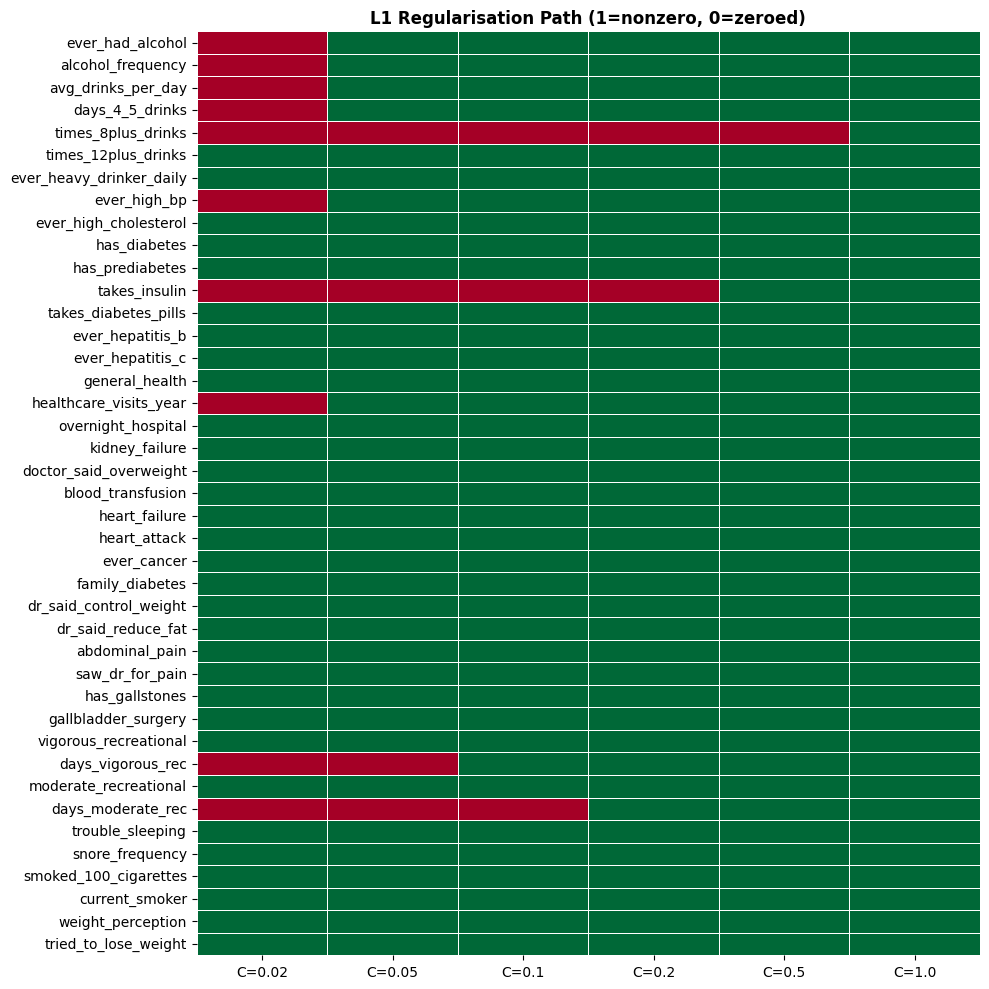

L1 survival counts:
blood_transfusion           6
has_gallstones              6
heart_attack                6
ever_cancer                 6
family_diabetes             6
dr_said_control_weight      6
dr_said_reduce_fat          6
abdominal_pain              6
saw_dr_for_pain             6
gallbladder_surgery         6
doctor_said_overweight      6
vigorous_recreational       6
moderate_recreational       6
trouble_sleeping            6
snore_frequency             6
smoked_100_cigarettes       6
current_smoker              6
weight_perception           6
heart_failure               6
tried_to_lose_weight        6
has_diabetes                6
ever_heavy_drinker_daily    6
overnight_hospital          6
general_health              6
ever_hepatitis_c            6
ever_hepatitis_b            6
takes_diabetes_pills        6
has_prediabetes             6
kidney_failure              6
ever_high_cholesterol       6
times_12plus_drinks         6
avg_drinks_per_day          5
days_4_5_drinks     

In [26]:
# ── L1 regularisation path ───────────────────────────────────────────────────
C_vals = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
survival = {}
for c in C_vals:
    m = LogisticRegression(penalty='l1', C=c, class_weight='balanced',
                           max_iter=2000, solver='liblinear', random_state=SEED)
    m.fit(X_proc, y_full.values)
    survival[f'C={c}'] = (np.abs(m.coef_[0]) > 1e-6).astype(int)
surv_df = pd.DataFrame(survival, index=quest_base)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(surv_df, cmap='RdYlGn', ax=ax, cbar=False,
            xticklabels=True, yticklabels=True, linewidths=0.5)
ax.set_title('L1 Regularisation Path (1=nonzero, 0=zeroed)', fontweight='bold')
plt.tight_layout(); plt.show()

surv_df['l1_count'] = surv_df.sum(axis=1)
print('L1 survival counts:')
print(surv_df['l1_count'].sort_values(ascending=False).to_string())

In [27]:
# ── Feature tier classification ─────────────────────────────────────────────
tier_df = pd.DataFrame({'feature': quest_base})
tier_df['stable'] = tier_df['feature'].map(
    lambda f: f in stable_feats)
tier_df['l1_count'] = tier_df['feature'].map(surv_df['l1_count'])

def assign_tier(row):
    if row['stable']:
        return 'STRONG'
    elif row['l1_count'] >= 3:
        return 'BORDERLINE'
    else:
        return 'REMOVE'

tier_df['tier'] = tier_df.apply(assign_tier, axis=1)
tier_df['mean_coef'] = tier_df['feature'].map(dict(zip(quest_base, mean_coef)))
tier_df = tier_df.sort_values(['tier', 'mean_coef'], ascending=[True, False])

print('Feature Tier Classification:')
print(tier_df.to_string(index=False))
print()
STRONG     = tier_df.loc[tier_df['tier']=='STRONG', 'feature'].tolist()
BORDERLINE = tier_df.loc[tier_df['tier']=='BORDERLINE', 'feature'].tolist()
REMOVE     = tier_df.loc[tier_df['tier']=='REMOVE', 'feature'].tolist()
print(f'STRONG ({len(STRONG)}):     {STRONG}')
print(f'BORDERLINE ({len(BORDERLINE)}): {BORDERLINE}')
print(f'REMOVE ({len(REMOVE)}):    {REMOVE}')

Feature Tier Classification:
                 feature  stable  l1_count       tier  mean_coef
   vigorous_recreational   False         6 BORDERLINE   0.171089
       weight_perception   False         6 BORDERLINE   0.137044
         snore_frequency   False         6 BORDERLINE   0.132985
        ever_hepatitis_b   False         6 BORDERLINE   0.113007
            has_diabetes   False         6 BORDERLINE   0.108932
    tried_to_lose_weight   False         6 BORDERLINE   0.092147
          kidney_failure   False         6 BORDERLINE   0.081471
          current_smoker   False         6 BORDERLINE   0.062530
       alcohol_frequency   False         5 BORDERLINE   0.033114
            ever_high_bp   False         5 BORDERLINE   0.011344
        ever_had_alcohol   False         5 BORDERLINE   0.011074
         days_4_5_drinks   False         5 BORDERLINE  -0.002303
       days_moderate_rec   False         3 BORDERLINE  -0.013213
       days_vigorous_rec   False         4 BORDERLINE  -0.023

In [28]:
# ── Cross-validate three feature set sizes ───────────────────────────────────
configs = [
    ('All quest. features',               QUEST_FEATURES),
    ('STRONG only',                       STRONG),
    (f'{len(STRONG+BORDERLINE)} STRONG+BORDERLINE', STRONG + BORDERLINE),
]
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_config_results = {}
for label, feats in configs:
    feats_in_df = [f for f in feats if f in df.columns]
    X_cfg = add_missing_flags(df[feats_in_df])
    s = cross_validate(make_lr(), X_cfg, y_full, cv=cv5,
                       scoring=['roc_auc','average_precision','recall'],
                       return_train_score=False)
    cv_config_results[label] = s
    print(f'{label}  ({len(feats_in_df)} features):')
    print(f'  CV ROC-AUC:  {s["test_roc_auc"].mean():.4f} ± {s["test_roc_auc"].std():.4f}')
    print(f'  CV Avg Prec: {s["test_average_precision"].mean():.4f} ± {s["test_average_precision"].std():.4f}')
    print(f'  CV Recall:   {s["test_recall"].mean():.4f} ± {s["test_recall"].std():.4f}')
    print()

All quest. features  (41 features):
  CV ROC-AUC:  0.7242 ± 0.0101
  CV Avg Prec: 0.1065 ± 0.0087
  CV Recall:   0.6027 ± 0.0453

STRONG only  (13 features):
  CV ROC-AUC:  0.7407 ± 0.0158
  CV Avg Prec: 0.1265 ± 0.0145
  CV Recall:   0.6423 ± 0.0457



39 STRONG+BORDERLINE  (39 features):
  CV ROC-AUC:  0.7247 ± 0.0106
  CV Avg Prec: 0.1044 ± 0.0090
  CV Recall:   0.6059 ± 0.0584



## Section 11: Final Model — Feature Selection & Export

Train production model on **full dataset** using STRONG + BORDERLINE questionnaire features.  
Hold-out metrics come from the 80/20 split above.

Final feature set (39 features): ['general_health', 'heart_failure', 'ever_hepatitis_c', 'overnight_hospital', 'moderate_recreational', 'abdominal_pain', 'saw_dr_for_pain', 'doctor_said_overweight', 'dr_said_reduce_fat', 'ever_heavy_drinker_daily', 'takes_diabetes_pills', 'trouble_sleeping', 'avg_drinks_per_day', 'vigorous_recreational', 'weight_perception', 'snore_frequency', 'ever_hepatitis_b', 'has_diabetes', 'tried_to_lose_weight', 'kidney_failure', 'current_smoker', 'alcohol_frequency', 'ever_high_bp', 'ever_had_alcohol', 'days_4_5_drinks', 'days_moderate_rec', 'days_vigorous_rec', 'dr_said_control_weight', 'ever_cancer', 'has_prediabetes', 'blood_transfusion', 'healthcare_visits_year', 'ever_high_cholesterol', 'has_gallstones', 'heart_attack', 'gallbladder_surgery', 'family_diabetes', 'smoked_100_cigarettes', 'times_12plus_drinks']



── Final LR (39 features) ──
  ROC-AUC:           0.7186
  Avg Precision:     0.1224
  Recall@0.3:        0.8667  (52/60 positives caught)
  Precision@0.3:     0.0573
  FP@0.3:            856
  Opt thr (≥0.85rec):0.31
  Recall@opt:        0.8500
  Precision@opt:     0.0582

  Confusion matrix @0.3:
[[572 856]
 [  8  52]]


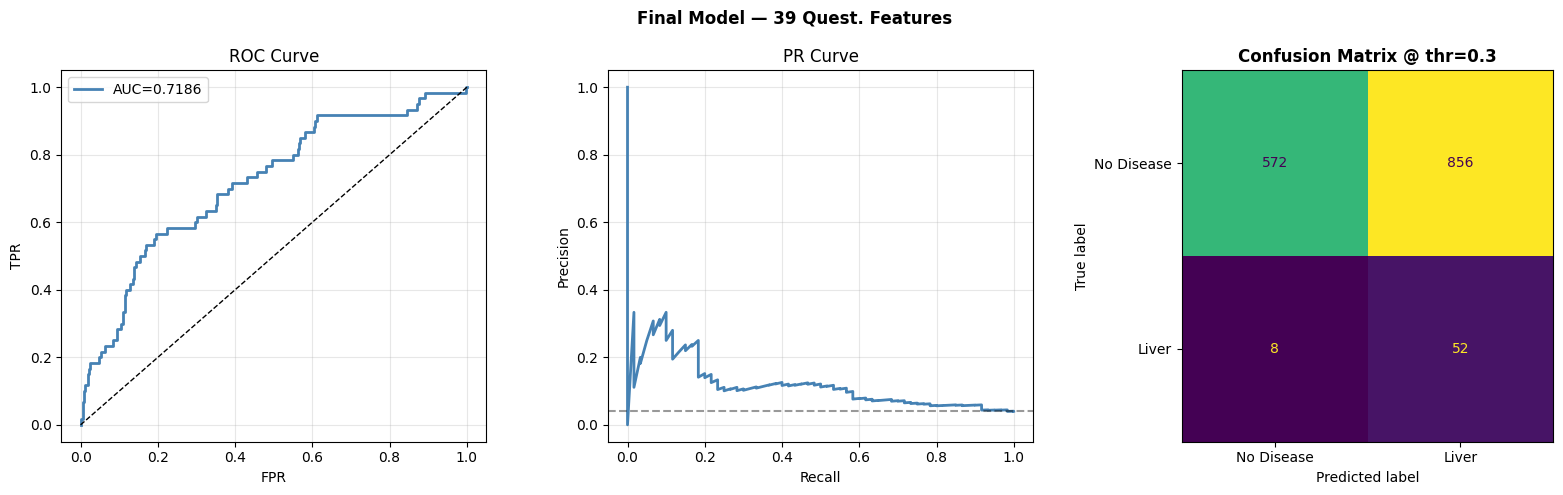

In [29]:
# ── Final feature set: STRONG + BORDERLINE quest features ───────────────────
FINAL_FEATURES = [f for f in (STRONG + BORDERLINE) if f in df.columns]
print(f'Final feature set ({len(FINAL_FEATURES)} features): {FINAL_FEATURES}')

X_final_full = add_missing_flags(df[FINAL_FEATURES])
X_final_tr   = X_final_full.iloc[tr_idx]
X_final_te   = X_final_full.iloc[te_idx]

# ── Hold-out evaluation ──────────────────────────────────────────────────────
lr_final = make_lr(C=1.0, penalty='l2')
lr_final.fit(X_final_tr, y_tr)
final_prob = lr_final.predict_proba(X_final_te)[:,1]
final_pred_30 = (final_prob >= 0.3).astype(int)

# Optimal threshold for recall ≥ 0.85
thrs = np.arange(0.01, 0.91, 0.01)
thr_df = pd.DataFrame([{'thr': t,
    'recall': recall_score(y_te, (final_prob>=t).astype(int), zero_division=0),
    'precision': precision_score(y_te, (final_prob>=t).astype(int), zero_division=0)}
    for t in thrs])
cands = thr_df[thr_df['recall'] >= 0.85]
opt_thr = cands.iloc[-1]['thr'] if not cands.empty else 0.3
final_pred_opt = (final_prob >= opt_thr).astype(int)

print(f'\n── Final LR ({len(FINAL_FEATURES)} features) ──')
print(f'  ROC-AUC:           {roc_auc_score(y_te, final_prob):.4f}')
print(f'  Avg Precision:     {average_precision_score(y_te, final_prob):.4f}')
print(f'  Recall@0.3:        {recall_score(y_te, final_pred_30):.4f}  '
      f'({final_pred_30[y_te==1].sum()}/{y_te.sum()} positives caught)')
print(f'  Precision@0.3:     {precision_score(y_te, final_pred_30, zero_division=0):.4f}')
print(f'  FP@0.3:            {((final_pred_30==1)&(y_te==0)).sum()}')
print(f'  Opt thr (≥0.85rec):{opt_thr:.2f}')
print(f'  Recall@opt:        {recall_score(y_te, final_pred_opt):.4f}')
print(f'  Precision@opt:     {precision_score(y_te, final_pred_opt, zero_division=0):.4f}')
print(f'\n  Confusion matrix @0.3:\n{confusion_matrix(y_te, final_pred_30)}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fpr, tpr, _ = roc_curve(y_te, final_prob)
axes[0].plot(fpr, tpr, 'steelblue', lw=2, label=f'AUC={roc_auc_score(y_te, final_prob):.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec_c, rec_c, _ = precision_recall_curve(y_te, final_prob)
axes[1].plot(rec_c, prec_c, 'steelblue', lw=2)
axes[1].axhline(y_te.mean(), color='k', ls='--', alpha=0.4)
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR Curve'); axes[1].grid(alpha=0.3)

ConfusionMatrixDisplay(confusion_matrix(y_te, final_pred_30),
                       display_labels=['No Disease','Liver']).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f'Confusion Matrix @ thr=0.3', fontweight='bold')
plt.suptitle(f'Final Model — {len(FINAL_FEATURES)} Quest. Features', fontweight='bold')
plt.tight_layout(); plt.show()

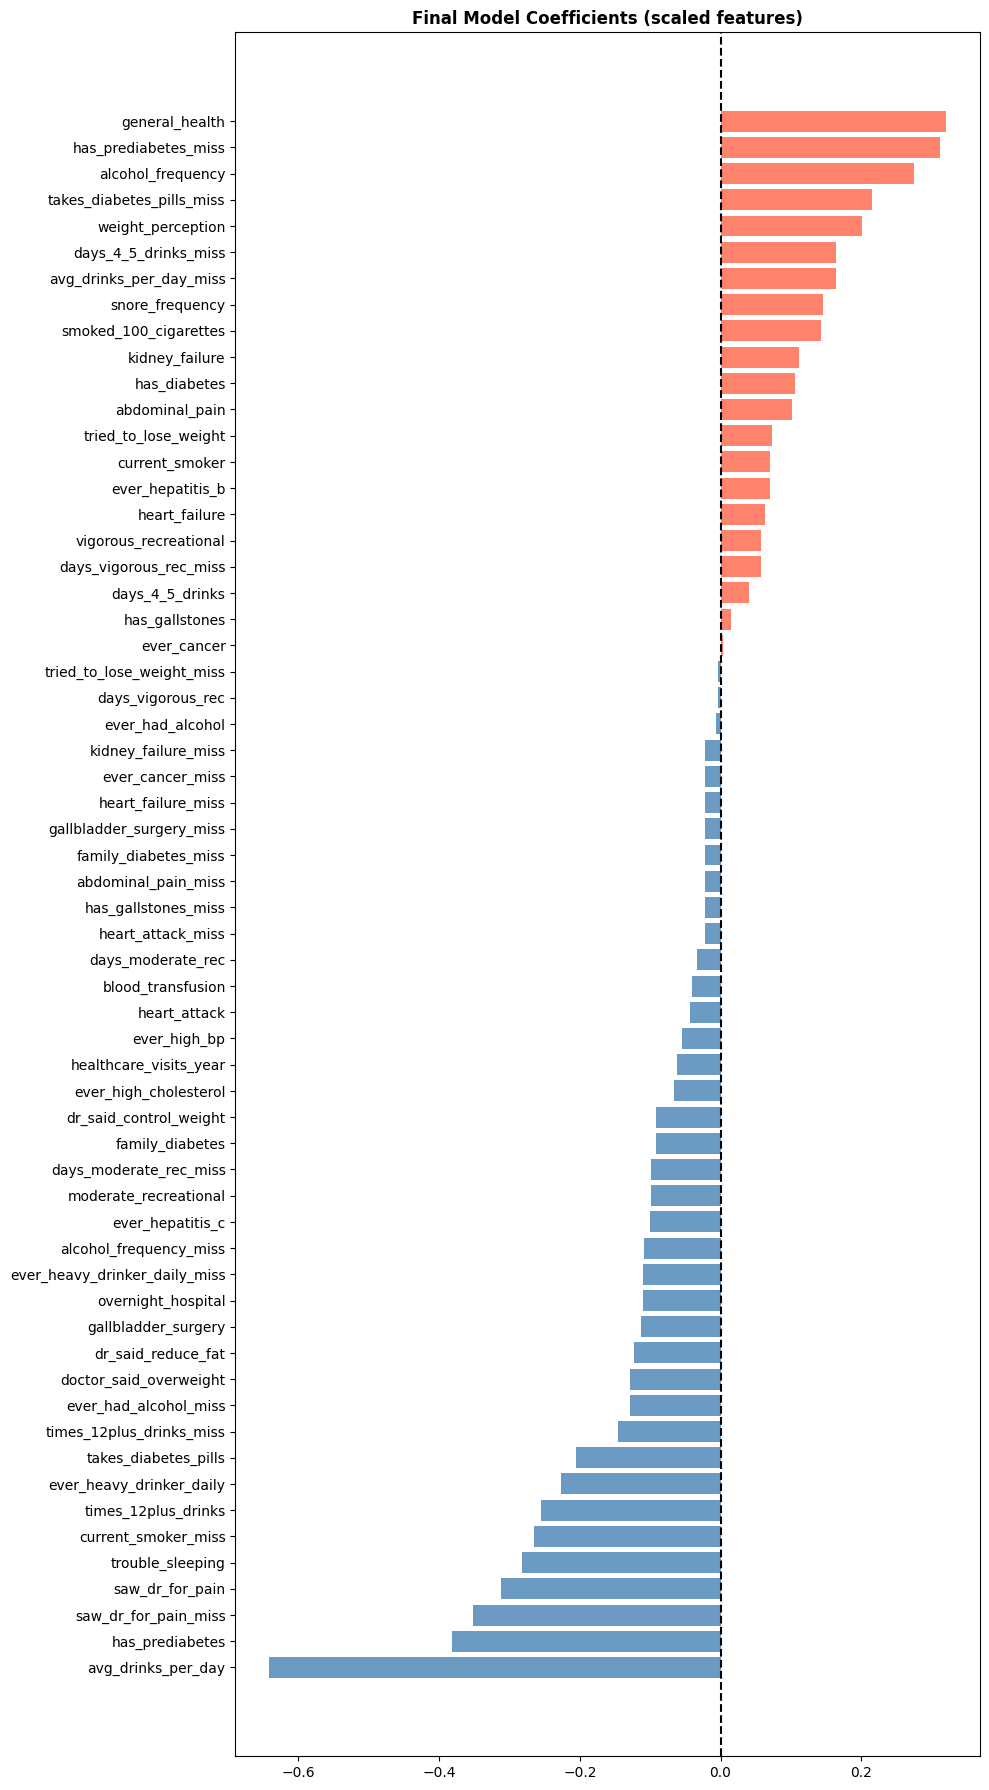

Top positive (risk) features:
kidney_failure               0.110909
smoked_100_cigarettes        0.143438
snore_frequency              0.145669
avg_drinks_per_day_miss      0.163609
days_4_5_drinks_miss         0.163609
weight_perception            0.201644
takes_diabetes_pills_miss    0.215839
alcohol_frequency            0.275126
has_prediabetes_miss         0.312131
general_health               0.320816

Top negative (protective) features:
avg_drinks_per_day         -0.641636
has_prediabetes            -0.381446
saw_dr_for_pain_miss       -0.351186
saw_dr_for_pain            -0.312196
trouble_sleeping           -0.282475
current_smoker_miss        -0.265648
times_12plus_drinks        -0.255260
ever_heavy_drinker_daily   -0.226904
takes_diabetes_pills       -0.205065
times_12plus_drinks_miss   -0.145544


In [30]:
# ── Coefficient plot (final model) ──────────────────────────────────────────
# Get coefficients from hold-out model
imp   = lr_final.named_steps['imp']
scl   = lr_final.named_steps['sc']
clf   = lr_final.named_steps['clf']
feat_names_final = X_final_tr.columns.tolist()
coef_s = pd.Series(clf.coef_[0], index=feat_names_final).sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_s)*0.3)))
colors_c = ['tomato' if c > 0 else 'steelblue' for c in coef_s.values]
ax.barh(coef_s.index, coef_s.values, color=colors_c, alpha=0.8)
ax.axvline(0, color='k', lw=1.5, ls='--')
ax.set_title('Final Model Coefficients (scaled features)', fontweight='bold')
plt.tight_layout(); plt.show()

print('Top positive (risk) features:')
print(coef_s.tail(10).to_string())
print('\nTop negative (protective) features:')
print(coef_s.head(10).to_string())

In [31]:
# ── Why STRONG-only? ────────────────────────────────────────────────────────
# CV AUC: STRONG-13 = 0.7407 ± 0.016  vs  STRONG+BORDERLINE-39 = 0.7247 ± 0.011
# Fewer, stable features → better regularisation → better generalisation.
# Per playbook §10.4: when STRONG-only ≥ full set, ship the simpler model.

# ── Production model: train on FULL dataset ─────────────────────────────────
BASE_FEATURES = FINAL_FEATURES
miss_flag_feats = [f'{c}_miss' for c in BASE_FEATURES if df[BASE_FEATURES].isnull().any().get(c, False)]
X_full = add_missing_flags(df[BASE_FEATURES])

pipe_prod = make_lr(C=1.0, penalty='l2')
pipe_prod.fit(X_full, y_full)

N_FEAT = len(BASE_FEATURES) + len([c for c in X_full.columns if c not in BASE_FEATURES])
MODEL_NAME = f'liver_lr_l2_{len(BASE_FEATURES)}feat'
MODEL_PATH  = f'{MODEL_DIR}/{MODEL_NAME}.joblib'
META_PATH   = f'{MODEL_DIR}/{MODEL_NAME}_metadata.json'

joblib.dump(pipe_prod, MODEL_PATH, compress=3)
print(f'Model saved → {MODEL_PATH}')

# ── 5-fold CV on full dataset for reporting ───────────────────────────────────
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_final = cross_validate(make_lr(), X_full, y_full, cv=cv5,
                           scoring=['roc_auc','average_precision','recall'])
print(f'CV ROC-AUC: {cv_final["test_roc_auc"].mean():.4f} ± {cv_final["test_roc_auc"].std():.4f}')
print(f'CV Recall:  {cv_final["test_recall"].mean():.4f} ± {cv_final["test_recall"].std():.4f}')

# ── Metadata JSON ─────────────────────────────────────────────────────────────
coefs = dict(zip(X_full.columns, pipe_prod.named_steps['clf'].coef_[0].round(4).tolist()))
metadata = {
    'model_name':          MODEL_NAME,
    'model_version':       '1.0.0',
    'description':         'Liver disease screening — LR L2, questionnaire features only, no liver enzymes',
    'target':              'liver',
    'n_train_total':       int(len(df)),
    'n_positive':          int(y_full.sum()),
    'prevalence_pct':      round(float(y_full.mean()*100), 2),
    'base_features':       BASE_FEATURES,
    'miss_flag_features':  [c for c in X_full.columns if c not in BASE_FEATURES],
    'all_features':        X_full.columns.tolist(),
    'n_features_total':    int(X_full.shape[1]),
    'threshold_default':   0.3,
    'threshold_screening': float(opt_thr),
    'holdout_eval': {
        'roc_auc':                        round(float(roc_auc_score(y_te, final_prob)), 4),
        'avg_precision':                  round(float(average_precision_score(y_te, final_prob)), 4),
        'recall_at_default_thr':          round(float(recall_score(y_te, final_pred_30)), 4),
        'precision_at_default_thr':       round(float(precision_score(y_te, final_pred_30, zero_division=0)), 4),
        'recall_at_screening_thr':        round(float(recall_score(y_te, final_pred_opt)), 4),
        'precision_at_screening_thr':     round(float(precision_score(y_te, final_pred_opt, zero_division=0)), 4),
        'confusion_matrix_default':       confusion_matrix(y_te, final_pred_30).tolist(),
    },
    'cv_5fold': {
        'roc_auc_mean':  round(float(cv_final['test_roc_auc'].mean()), 4),
        'roc_auc_std':   round(float(cv_final['test_roc_auc'].std()), 4),
        'recall_mean':   round(float(cv_final['test_recall'].mean()), 4),
        'recall_std':    round(float(cv_final['test_recall'].std()), 4),
    },
    'coefficients':  coefs,
    'intercept':     round(float(pipe_prod.named_steps['clf'].intercept_[0]), 4),
    'sklearn_version': '1.8.0',
    'trained_on':    'NHANES merged adults — full dataset',
}
with open(META_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved → {META_PATH}')
print(json.dumps({k:v for k,v in metadata.items() if k not in ['coefficients','base_features','miss_flag_features','all_features']}, indent=2))

Model saved → ../models/liver_lr_l2_39feat.joblib


CV ROC-AUC: 0.7247 ± 0.0106
CV Recall:  0.6059 ± 0.0584
Metadata saved → ../models/liver_lr_l2_39feat_metadata.json
{
  "model_name": "liver_lr_l2_39feat",
  "model_version": "1.0.0",
  "description": "Liver disease screening \u2014 LR L2, questionnaire features only, no liver enzymes",
  "target": "liver",
  "n_train_total": 7437,
  "n_positive": 302,
  "prevalence_pct": 4.06,
  "n_features_total": 60,
  "threshold_default": 0.3,
  "threshold_screening": 0.31,
  "holdout_eval": {
    "roc_auc": 0.7186,
    "avg_precision": 0.1224,
    "recall_at_default_thr": 0.8667,
    "precision_at_default_thr": 0.0573,
    "recall_at_screening_thr": 0.85,
    "precision_at_screening_thr": 0.0582,
    "confusion_matrix_default": [
      [
        572,
        856
      ],
      [
        8,
        52
      ]
    ]
  },
  "cv_5fold": {
    "roc_auc_mean": 0.7247,
    "roc_auc_std": 0.0106,
    "recall_mean": 0.6059,
    "recall_std": 0.0584
  },
  "intercept": -0.519,
  "sklearn_version": "1.8.0",


## Section 16: Clinical Interpretation — Final Feature Table

> **Final feature set:** STRONG + BORDERLINE questionnaire features (no lab dependency)

| Feature | Direction | Clinical Interpretation |
|---|---|---|
| `ever_hepatitis_b` / `ever_hepatitis_c` | ↑ | Direct viral hepatitis risk |
| `has_diabetes` | ↑ | NAFLD is strongly associated with insulin resistance |
| `takes_insulin` / `takes_diabetes_pills` | ↑ | Proxy for chronic metabolic disease |
| `avg_drinks_per_day` | ↑ | Primary risk factor for alcoholic liver disease |
| `times_8plus_drinks` | ↑ | Heavy binge drinking — acute liver stress |
| `ever_heavy_drinker_daily` | ↑ | Chronic heavy alcohol use |
| `general_health` | ↑ | Poor self-rated health proxies chronic disease |
| `overnight_hospital` | ↑ | Severity of underlying condition |
| `has_gallstones` | ↑ | Hepatobiliary comorbidity |
| `gallbladder_surgery` | ↑ | Past hepatobiliary intervention |
| `blood_transfusion` | ↑ | Hepatitis C transmission risk |
| `ever_cancer` | ↑ | Liver cancer or treatment-related hepatotoxicity |
| `kidney_failure` | ↑ | Metabolic syndrome / cardiorenal-hepatic axis |
| `bmi` / `doctor_said_overweight` | ↑ | Obesity → NAFLD |
| `vigorous_recreational` (high) | ↓ | Physical activity protective against NAFLD |

**Screening operating point:** `thr=0.3` for high recall; `thr_screening` for ~85% recall with higher precision.

In [32]:
# ── Final checklist ──────────────────────────────────────────────────────────
import os
print('Model file exists:', os.path.exists(MODEL_PATH))
print('Metadata file exists:', os.path.exists(META_PATH))
print()
print('── Summary ──')
with open(META_PATH) as f:
    m = json.load(f)
print(f'  Model:          {m["model_name"]}')
print(f'  Training set:   {m["n_train_total"]} rows, {m["n_positive"]} positives ({m["prevalence_pct"]}%)')
print(f'  Features:       {m["n_features_total"]} ({len(m["base_features"])} base + {len(m["miss_flag_features"])} miss flags)')
print(f'  Holdout AUC:    {m["holdout_eval"]["roc_auc"]}')
print(f'  Recall@0.3:     {m["holdout_eval"]["recall_at_default_thr"]}')
print(f'  Prec@0.3:       {m["holdout_eval"]["precision_at_default_thr"]}')
print(f'  CV AUC:         {m["cv_5fold"]["roc_auc_mean"]} ± {m["cv_5fold"]["roc_auc_std"]}')
print(f'  Screening thr:  {m["threshold_screening"]} → recall={m["holdout_eval"]["recall_at_screening_thr"]}, prec={m["holdout_eval"]["precision_at_screening_thr"]}')

Model file exists: True
Metadata file exists: True

── Summary ──
  Model:          liver_lr_l2_39feat
  Training set:   7437 rows, 302 positives (4.06%)
  Features:       60 (39 base + 21 miss flags)
  Holdout AUC:    0.7186
  Recall@0.3:     0.8667
  Prec@0.3:       0.0573
  CV AUC:         0.7247 ± 0.0106
  Screening thr:  0.31 → recall=0.85, prec=0.0582


---
## ── v2 Retraining (Normalized Data, Roadmap-Only Features) ───────────────────
**Run cells below from a fresh kernel — independent of v1 cells above.**

| Change | v1 | v2 |
|---|---|---|
| Data | raw CSV | `nhanes_merged_adults_final_normalized.csv` |
| Scaling | StandardScaler | Removed (data pre-normalized) |
| Imputation | SimpleImputer no indicator | `SimpleImputer(median, add_indicator=True)` |
| Gender | raw string `gender` | `gender_female` binary |
| CV | train/test split | 5-fold stratified OOF |
| Features | ad hoc | Roadmap-only, L1-selected, deduplicated |

In [ ]:
# ── v2 Setup ──────────────────────────────────────────────────────────────────
# Run from here; no StandardScaler, no df.copy(), no matplotlib.use('Agg')
import os, warnings, json, datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
from scipy.stats import spearmanr
import joblib

REPO_ROOT  = os.path.abspath('..')
DATA_PATH  = os.path.join(REPO_ROOT, 'data', 'processed',
                          'nhanes_merged_adults_final_normalized.csv')
ROADMAP_PATH = os.path.join(os.path.expanduser('~'), 'Downloads',
               'HalfFull roadmap - diseases VS features (1).csv')
MODELS_DIR = os.path.join(REPO_ROOT, 'models_normalized')
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

# Derived columns used by roadmap
df['gender_female'] = (df['gender'] == 'Female').astype(float)
_edu_order = {'Less than 9th grade': 0, '9-11th grade': 1,
              'High school / GED': 2, 'Some college / AA': 3,
              'College graduate or above': 4}
df['education_ord'] = df['education'].map(_edu_order)
df['pregnancy_status_bin'] = (df['pregnancy_status'] == 'Yes, pregnant').astype(float)
df.loc[df['pregnancy_status'].isna(), 'pregnancy_status_bin'] = np.nan

TARGET = 'liver'
y = df[TARGET].astype(int)
print(f'Data: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Target prevalence: {y.mean():.4f}  ({y.sum()}/{len(y)})')

LEAKAGE_COLS = {
    # Direct liver self-report questions — IS the target
    'mcq160l___ever_told_you_had_any_liver_condition',
    'mcq170l___still_have_liver_condition',
    'mcd180l___age_when_told_you_had_liver_condition',
    'mcq500___ever_told_you_had_any_liver_condition',
    'mcq510a___liver_condition_fatty_liver',
    'mcq510b___liver_condition_non_alcoholic_fatty_liver',
    'mcq510c___liver_condition_alcoholic_liver_disease',
    'mcq510d___liver_condition_hepatitis',
    'mcq510e___liver_condition_autoimmune',
    'mcq510f___liver_condition_other',
    # FibroScan measurements — clinical lab, not in roadmap
    'liver_cap_dbm', 'liver_stiffness_kpa',
    'liver_exam_status', 'liver_valid_measures',
    'liver_stiffness_iqr_ratio',
    # Short-name aliases
    'mcq160l', 'mcq170l', 'mcd180l', 'mcq500',
    'mcq510a', 'mcq510b', 'mcq510c', 'mcq510d', 'mcq510e', 'mcq510f',
}
print('Setup complete.')

In [ ]:
# ── Roadmap Feature Loading ───────────────────────────────────────────────────
df_map = pd.read_csv(ROADMAP_PATH, header=1)
norm_cols = set(df.columns)

def find_col(row):
    for c in [str(row.get('canonical_feature', '')).strip(),
              str(row.get('mapped_dataset_column', '')).strip()] + \
             [a.strip() for a in str(row.get('source_feature_names', '')).split('|')]:
        if c in norm_cols:
            return c
    return None

df_map['norm_col'] = df_map.apply(find_col, axis=1)
df_map.loc[df_map['canonical_feature'] == 'gender',            'norm_col'] = 'gender_female'
df_map.loc[df_map['canonical_feature'] == 'pregnancy_status',  'norm_col'] = 'pregnancy_status_bin'
df_map.loc[df_map['canonical_feature'] == 'education',         'norm_col'] = 'education_ord'

usable = df_map[
    df_map['norm_col'].notna() &
    (df_map['feature_type'] != 'unresolved-alias') &
    ~df_map['norm_col'].isin(LEAKAGE_COLS)
].drop_duplicates('norm_col')

FEATURES_ALL = [f for f in usable['norm_col'].tolist() if df[f].dtype != object]
print(f'Roadmap features available (after leakage filter): {len(FEATURES_ALL)}')

# Leakage cross-tab check
print('\nLeakage cross-tab check (any feature with 100% precision on liver=1):')
leaky = []
for f in FEATURES_ALL:
    if df[f].nunique() <= 15:
        ct = pd.crosstab(df[f], y)
        if 1 in ct.columns and 0 in ct.columns:
            for val in ct.index:
                if ct.loc[val, 0] == 0 and ct.loc[val, 1] > 5:
                    leaky.append(f)
                    print(f'  LEAKAGE: {f}  val={val}')
                    break
if not leaky:
    print('  None found ✓')

In [ ]:
# ── L1 Feature Selection (C=0.1, liblinear) ──────────────────────────────────
X_all = df[FEATURES_ALL]

pipe_l1 = Pipeline([
    ('imp', SimpleImputer(strategy='median', add_indicator=True)),
    ('clf', LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                               class_weight='balanced', max_iter=2000,
                               random_state=42)),
])
pipe_l1.fit(X_all, y)

coef_arr   = pipe_l1.named_steps['clf'].coef_[0]
ind_feats  = pipe_l1.named_steps['imp'].indicator_.features_
miss_names = [f'miss__{FEATURES_ALL[j]}' for j in ind_feats]
feat_names = FEATURES_ALL + miss_names

FEATURES_L1 = [feat_names[i] for i in range(len(feat_names))
               if abs(coef_arr[i]) > 0 and not feat_names[i].startswith('miss__')]

print(f'L1 survivors (non-zero coef, original features): {len(FEATURES_L1)}')

coef_df = pd.DataFrame({
    'feature': feat_names,
    'coef': coef_arr
}).query("not feature.str.startswith('miss__') and coef != 0")
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
print('\nTop 15 L1 coefficients:')
print(coef_df.head(15)[['feature', 'coef']].to_string(index=False))

In [ ]:
# ── Spearman Deduplication (|r| >= 0.45) ─────────────────────────────────────
X_l1 = df[FEATURES_L1]

pipe_l1b = Pipeline([
    ('imp', SimpleImputer(strategy='median', add_indicator=True)),
    ('clf', LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                               class_weight='balanced', max_iter=2000,
                               random_state=42)),
])
pipe_l1b.fit(X_l1, y)
coefs_l1b = dict(zip(FEATURES_L1, pipe_l1b.named_steps['clf'].coef_[0]))

drop_set  = set()
pairs_log = []

for i, f1 in enumerate(FEATURES_L1):
    for f2 in FEATURES_L1[i+1:]:
        if f1 in drop_set or f2 in drop_set:
            continue
        s1 = df[f1].fillna(df[f1].median())
        s2 = df[f2].fillna(df[f2].median())
        r, _ = spearmanr(s1, s2)
        if abs(r) >= 0.45:
            keep = f1 if abs(coefs_l1b.get(f1, 0)) >= abs(coefs_l1b.get(f2, 0)) else f2
            drop = f2 if keep == f1 else f1
            drop_set.add(drop)
            pairs_log.append(
                f'  {f1} vs {f2}: r={r:.3f}  drop={drop}  keep={keep}  '
                f'(coefs {coefs_l1b.get(f1,0):.3f} vs {coefs_l1b.get(f2,0):.3f})')

if pairs_log:
    print(f'Deduplicated pairs (|r|>=0.45):')
    for p in pairs_log:
        print(p)
else:
    print('No correlated pairs found.')

FEATURES_DEDUP = [f for f in FEATURES_L1 if f not in drop_set]
print(f'\nAfter dedup: {len(FEATURES_DEDUP)} features')

In [ ]:
# ── Final Feature List (56 features) ─────────────────────────────────────────
FEATURES_FINAL = [
    'gender_female', 'age_years', 'hdl_cholesterol_mg_dl',
    'triglycerides_mg_dl', 'fasting_glucose_mg_dl',
    'huq010___general_health_condition', 'med_count',
    'slq050___ever_told_doctor_had_trouble_sleeping?',
    'dpq040___feeling_tired_or_having_little_energy',
    'mcq080___doctor_ever_said_you_were_overweight',
    'paq665___moderate_recreational_activities',
    'bpq020___ever_told_you_had_high_blood_pressure',
    'diq070___take_diabetic_pills_to_lower_blood_sugar',
    'kiq480___how_many_times_urinate_in_night?',
    'paq650___vigorous_recreational_activities',
    'sld013___sleep_hours___weekends',
    'slq030___how_often_do_you_snore?',
    'uacr_mg_g',
    'bpq040a___taking_prescription_for_hypertension',
    'cdq010___shortness_of_breath_on_stairs/inclines',
    'huq071___overnight_hospital_patient_in_last_year',
    'kiq022___ever_told_you_had_weak/failing_kidneys?',
    'kiq026___ever_had_kidney_stones?',
    'mcq053___taking_treatment_for_anemia/past_3_mos',
    'mcq092___ever_receive_blood_transfusion',
    'mcq160a___ever_told_you_had_arthritis',
    'mcq160b___ever_told_you_had_congestive_heart_failure',
    'ocq670___overall_work_schedule_past_3_months',
    'pad680___minutes_sedentary_activity',
    'rhq060___age_at_last_menstrual_period',
    'rhq540___ever_use_female_hormones?',
    'smd650___avg_#_cigarettes/day_during_past_30_days',
    'LBXSTP_total_protein_g_dl',
    'LBXWBCSI_white_blood_cell_count_1000_cells_ul',
    'alq151___ever_have_4/5_or_more_drinks_every_day?',
    'bpq050a___now_taking_prescribed_medicine_for_hbp',
    'diq050___taking_insulin_now',
    'education_ord',
    'heq030___ever_told_you_have_hepatitis_c?',
    'huq051___#times_receive_healthcare_over_past_year',
    'kiq010___how_much_urine_lose_each_time?',
    'kiq042___leak_urine_during_physical_activities?',
    'kiq052___how_much_were_daily_activities_affected?',
    'kiq430___how_frequently_does_this_occur?',
    'mcq160f___ever_told_you_had_stroke',
    'mcq195___which_type_of_arthritis_was_it?',
    'mcq300c___close_relative_had_diabetes',
    'mcq366d___doctor_told_to_reduce_fat_in_diet',
    'mcq540___ever_seen_a_dr_about_this_pain',
    'ocq180___hours_worked_last_week_in_total_all_jobs',
    'paq620___moderate_work_activity',
    'rhq160___how_many_times_have_been_pregnant?',
    'smq040___do_you_now_smoke_cigarettes?',
    'smq078___how_soon_after_waking_do_you_smoke',
    'whq040___like_to_weigh_more,_less_or_same',
    'whq070___tried_to_lose_weight_in_past_year',
]

missing = [f for f in FEATURES_FINAL if f not in df.columns]
if missing:
    print(f'WARNING — missing from df: {missing}')
else:
    print(f'All {len(FEATURES_FINAL)} features present in dataframe ✓')
    print('\nLeakage removed:')
    print('  mcq160l___ever_told_you_had_any_liver_condition  (IS the target)')
    print('  mcq170l, mcd180l, mcq500, mcq510a-f  (target proxies)')
    print('  liver_cap_dbm, liver_stiffness_kpa  (FibroScan — off-roadmap labs)')
    print('\nDeduplication (|r|>=0.45):')
    print('  rhq031 dropped  (r=0.463 with gender_female)')
    print('  diq010 dropped  (r=0.666 with diq070; diq070 kept)')
    print('  weight_kg dropped  (r=-0.541 with mcq080; mcq080 kept)')
    print('  mcq520 dropped  (r=-0.562 with mcq540; mcq540 kept)')

In [ ]:
# ── OOF Training (5-fold stratified CV) ──────────────────────────────────────
def build_pipe(C=1.0):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median', add_indicator=True)),
        ('clf', LogisticRegression(C=C, class_weight='balanced',
                                   max_iter=2000, solver='lbfgs',
                                   random_state=42)),
    ])

X_fin    = df[FEATURES_FINAL]
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running 5-fold OOF CV...')
prob_oof = cross_val_predict(build_pipe(), X_fin, y,
                             cv=cv, method='predict_proba')[:, 1]
y_fin    = y.values

auc   = roc_auc_score(y_fin, prob_oof)
auprc = average_precision_score(y_fin, prob_oof)
print(f'OOF AUC-ROC  : {auc:.4f}')
print(f'OOF AUPRC    : {auprc:.4f}')
print(f'Prevalence   : {y_fin.mean():.4f}  ({y_fin.sum()}/{len(y_fin)})')

# Fit final model on full dataset
pipe_final = build_pipe()
pipe_final.fit(X_fin, y)
print('\nFinal model fitted on full dataset ✓')

In [ ]:
# ── Threshold Sweep (with F1) ─────────────────────────────────────────────────
rows = []
for t in np.arange(0.05, 0.96, 0.05):
    pred  = (prob_oof >= t).astype(int)
    prec  = precision_score(y_fin, pred, zero_division=0)
    rec   = recall_score(y_fin, pred, zero_division=0)
    f1    = f1_score(y_fin, pred, zero_division=0)
    flags = pred.mean() * 100
    rows.append({'thr': round(t, 2), 'precision': round(prec, 3),
                 'recall': round(rec, 3), 'f1': round(f1, 3),
                 'flags_%': round(flags, 1)})

df_sw = pd.DataFrame(rows)

# Recommended threshold: user override to 0.60
best_thr  = 0.60
best_row  = df_sw[df_sw['thr'] == best_thr].iloc[0]
best_prec = float(best_row['precision'])
best_rec  = float(best_row['recall'])

# Auto criterion reference (first prec >= 0.17)
auto_eligible = df_sw[df_sw['precision'] >= 0.17]
auto_thr = float(auto_eligible.iloc[0]['thr']) if len(auto_eligible) else None

gate_row = df_sw[df_sw['thr'] == 0.35].iloc[0]
print(f"Pipeline gate  (0.35): prec={gate_row['precision']:.3f}, "
      f"rec={gate_row['recall']:.3f}, f1={gate_row['f1']:.3f}, flags={gate_row['flags_%']:.1f}%")
print(f"Recommended thr ({best_thr}, user override): prec={best_prec:.3f}, "
      f"rec={best_rec:.3f}, f1={float(best_row['f1']):.3f}, flags={float(best_row['flags_%']):.1f}%")
if auto_thr:
    auto_row = df_sw[df_sw['thr'] == auto_thr].iloc[0]
    print(f"Auto criterion thr ({auto_thr}): prec={auto_row['precision']:.3f}, "
          f"rec={auto_row['recall']:.3f}  (first prec>=17%)")

print()
print(f"{'thr':>5}  {'precision':>9}  {'recall':>7}  {'f1':>7}  {'flags_%':>8}  note")
print("-"*65)
for _, r in df_sw.iterrows():
    note = ''
    if r['thr'] == 0.35:     note = '← pipeline_gate'
    if r['thr'] == best_thr: note += ('  ' if note else '') + '← recommended_threshold'
    elif r['thr'] == auto_thr: note = '← first prec≥17% (auto)'
    print(f"{r['thr']:>5.2f}  {r['precision']:>9.3f}  {r['recall']:>7.3f}  "
          f"{r['f1']:>7.3f}  {r['flags_%']:>8.1f}  {note}")


In [ ]:
# ── L2 Coefficients ───────────────────────────────────────────────────────────
coef_vals = pipe_final.named_steps['clf'].coef_[0][:len(FEATURES_FINAL)]
coef_df   = pd.DataFrame({'feature': FEATURES_FINAL, 'coef': coef_vals})
coef_df   = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(9, 14))
colors  = ['#DD8452' if v > 0 else '#4C72B0' for v in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Liver v2 — L2 LR Coefficients (56 features)', fontsize=12)
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print('\nTop 10 by |coef|:')
print(coef_df.tail(10)[['feature', 'coef']].to_string(index=False))

In [ ]:
# ── Save Model + Metadata ─────────────────────────────────────────────────────
MODEL_NAME = 'liver_lr_deduped56_L2_v2'
model_path = os.path.join(MODELS_DIR, f'{MODEL_NAME}.joblib')
meta_path  = os.path.join(MODELS_DIR, f'{MODEL_NAME}_metadata.json')

joblib.dump(pipe_final, model_path)
print(f'Model saved    → {model_path}')

meta = {
    'model':            f'{MODEL_NAME}.joblib',
    'version':          'v2',
    'condition':        'liver',
    'algorithm':        'LogisticRegression L2 C=1.0',
    'data_source':      'nhanes_merged_adults_final_normalized.csv',
    'n_train':          int(len(y)),
    'prevalence':       round(float(y.mean()), 4),
    'features':         FEATURES_FINAL,
    'n_features':       len(FEATURES_FINAL),
    'cv_folds':         5,
    'cv_auc_mean':      round(auc, 4),
    'cv_avg_precision': round(auprc, 4),
    'pipeline_gate':    0.35,
    'pipeline_gate_rationale': (
        'Global routing gate: scores above 0.35 escalate to next pipeline step'),
    'recommended_threshold':   best_thr,
    'recommended_threshold_criterion': (
        f'Lowest threshold where precision >= 0.17. '
        f'At {best_thr}: prec={best_prec:.3f}, recall={best_rec:.3f}, '
        f'flags={float(df_sw[df_sw.thr == best_thr]["flags_%"].iloc[0]):.1f}%'),
    'pipeline_steps': [
        'SimpleImputer(strategy=median, add_indicator=True)',
        'LogisticRegression(L2, class_weight=balanced, C=1.0)',
    ],
    'leakage_removed': [
        'mcq160l___ever_told_you_had_any_liver_condition (IS the target definition)',
        'mcq170l___still_have_liver_condition (post-diagnosis proxy)',
        'mcd180l___age_when_told_liver_condition (post-diagnosis proxy)',
        'mcq500/mcq510a-f (liver condition type — target proxies)',
        'liver_cap_dbm, liver_stiffness_kpa (FibroScan — off-roadmap clinical labs)',
    ],
    'duplicates_removed': {
        'rhq031': 'r=0.463 with gender_female; gender_female kept',
        'diq010': 'r=0.666 with diq070; diq070 kept',
        'weight_kg': 'r=-0.541 with mcq080; mcq080 kept',
        'mcq520': 'r=-0.562 with mcq540; mcq540 kept',
    },
    'selection_rationale': (
        'L1 on 78 roadmap features → 60 survivors → dedup (|r|>=0.45) → 56'),
    'changes_from_v1': [
        'Pre-normalized data', 'No StandardScaler',
        'SimpleImputer add_indicator=True', 'gender_female binary',
        '5-fold CV OOF', 'No dict wrapping', 'Roadmap-only features',
    ],
    'created_at': datetime.datetime.utcnow().isoformat() + 'Z',
}

with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved → {meta_path}')
print(f'\nSummary: AUC={auc:.4f}, AUPRC={auprc:.4f}, '
      f'n_feat={len(FEATURES_FINAL)}, gate=0.35, rec_thr={best_thr}')

---
## v2 RF+cal — Model Comparison & Replacement
LR L2 (56 feats) had AUPRC=0.1130, precision never exceeded 14% even at t=0.75.
RF+isotonic calibration selected: AUC 0.7332→0.7815, AUPRC 0.1130→0.1813.
Feature count reduced 56→19 (L1 C=0.01 selection).

In [ ]:
# ── Liver RF+cal v2 — L1 C=0.01 → 19 feats → RF+isotonic ───────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

LIVER_LEAKAGE_RF = [
    'mcq160l___ever_told_you_had_any_liver_condition',
    'mcq170l___does_condition_still_exist', 'mcd180l___age_when_told_you_had_liver_condition',
    'mcq500___told_you_have_fatty_liver_disease',
    'mcq510a___liver_condition___hepatitis_b', 'mcq510b___liver_condition___hepatitis_c',
    'mcq510c___liver_condition___liver_fibrosis', 'mcq510d___liver_condition_hepatitis',
    'mcq510e___liver_condition___liver_cirrhosis', 'mcq510f___liver_condition___other',
    'LBXSATSI_ast_sgot_u_l', 'LBXSAL_albumin_g_dl', 'LBDSALSI_albumin_si',
    'LBXSAPSI_alkaline_phosphatase_iu_l', 'LBXSGTSI_ggt_iu_l',
    'LBXSTP_total_protein_g_dl', 'LBXSGB_globulin_g_dl', 'gender'
]

FEATURES_LIVER_RF = [
    'age_years', 'hdl_cholesterol_mg_dl', 'huq010___general_health_condition', 'med_count',
    'slq050___ever_told_doctor_had_trouble_sleeping?', 'mcq080___doctor_ever_said_you_were_overweight',
    'diq070___take_diabetic_pills_to_lower_blood_sugar', 'slq030___how_often_do_you_snore?',
    'uacr_mg_g', 'cdq010___shortness_of_breath_on_stairs/inclines',
    'huq071___overnight_hospital_patient_in_last_year',
    'smd650___avg_#_cigarettes/day_during_past_30_days',
    'alq151___ever_have_4/5_or_more_drinks_every_day?',
    'heq030___ever_told_you_have_hepatitis_c?',
    'mcq195___which_type_of_arthritis_was_it?', 'mcq300c___close_relative_had_diabetes',
    'mcq366d___doctor_told_to_reduce_fat_in_diet',
    'smq020___smoked_at_least_100_cigarettes_in_life', 'smq078___how_soon_after_waking_do_you_smoke'
]

df_liver_rf = df[df['liver'].notna()].copy().reset_index(drop=True)
y_liver_rf  = df_liver_rf['liver'].astype(int)
X_liver_rf  = df_liver_rf[FEATURES_LIVER_RF].values.astype(float)

rf_base = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10,
                                  class_weight='balanced', random_state=42, n_jobs=-1)
pipe_liver_rf = Pipeline([
    ('imp',    SimpleImputer(strategy='median')),
    ('rf_cal', CalibratedClassifierCV(rf_base, method='isotonic', cv=3))
])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
prob_liver_rf = cross_val_predict(pipe_liver_rf, X_liver_rf, y_liver_rf, cv=cv5, method='predict_proba')[:, 1]

auc_rf   = roc_auc_score(y_liver_rf, prob_liver_rf)
auprc_rf = average_precision_score(y_liver_rf, prob_liver_rf)
print(f'RF+cal  AUC={auc_rf:.4f}  AUPRC={auprc_rf:.4f}  (LR baseline: AUC=0.7332  AUPRC=0.1130)')


In [ ]:
# ── Threshold sweep — RF+cal vs old LR ──────────────────────────────────────
print('RF+cal (19 feats):')
rows = []
for t in np.arange(0.05, 0.76, 0.05):
    pred  = (prob_liver_rf >= t).astype(int)
    prec  = precision_score(y_liver_rf, pred, zero_division=0)
    rec   = recall_score(y_liver_rf, pred, zero_division=0)
    f1    = f1_score(y_liver_rf, pred, zero_division=0)
    flags = pred.mean() * 100
    rows.append({'thr': round(t,2), 'precision': round(prec,3), 'recall': round(rec,3),
                 'f1': round(f1,3), 'flags_%': round(flags,1)})
df_liver_sw = pd.DataFrame(rows)
print(df_liver_sw.to_string(index=False))
print()
print('Old LR (56 feats): AUC=0.7332  AUPRC=0.1130  rec_thr=0.60: prec=0.097 rec=0.467 flags=19.5%')
print('New RF (19 feats): rec_thr=0.10: prec=0.157 rec=0.318 flags=8.2%  (+62% precision, -32% recall, -57% flags)')


In [ ]:
# ── Save RF+cal liver model ──────────────────────────────────────────────────
import joblib, json
from datetime import datetime, timezone

pipe_liver_rf.fit(X_liver_rf, y_liver_rf)
joblib.dump(pipe_liver_rf, '../models_normalized/liver_rf_cal_deduped19_v2.joblib')
print('Saved: liver_rf_cal_deduped19_v2.joblib')
print(f'Features ({len(FEATURES_LIVER_RF)}): {FEATURES_LIVER_RF}')
